# 03 Descriptive Statistics

This notebook presents descriptive statistics, correlation analyses, and panel coverage/balance summaries for the monetary policy and FDI dataset.

In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Set matplotlib cache directory to avoid permissions issues
os.environ.setdefault('MPLCONFIGDIR', str(Path.cwd() / '.matplotlib_cache'))

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import FIGURES_DIR, OUTPUTS_DIR, PROCESSED_PANEL_FILE, ensure_output_dirs
from src.plot_helpers import correlation_heatmap, save_figure, setup_matplotlib_style

ensure_output_dirs()
setup_matplotlib_style()

df = pd.read_csv(PROCESSED_PANEL_FILE)
print(f"Loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns.")

Loaded dataset with 154 rows and 18 columns.


## 1. Dataset Overview

We begin by looking at the basic dimensions of the dataset, including the number of observations, country coverage, and year range.

In [2]:
overview_data = {
    'Metric': [
        'Total Observations',
        'Number of Countries',
        'First Year',
        'Last Year',
        'Total Panel Time Span (years)'
    ],
    'Value': [
        len(df),
        df['country'].nunique(),
        int(df['year'].min()),
        int(df['year'].max()),
        int(df['year'].max() - df['year'].min() + 1)
    ]
}
display(pd.DataFrame(overview_data))

,Metric,Value
0,Total Observations,154
1,Number of Countries,11
2,First Year,2010
3,Last Year,2023
4,Total Panel Time Span (years),14


## 2. Variable Summary Statistics

Below we calculate descriptive statistics for the dependent variable, monetary policy proxies, and control variables. We include the mean, standard deviation, minimum, maximum, and missingness metrics (count and percentage). We also display statistics for both the raw and winsorized versions of variables where winsorization was applied (FDI percentage of GDP and Exchange Rate Depreciation).

In [3]:
main_variables = [
    'fdi_pct_gdp',
    'fdi_pct_gdp_winsorized',
    'broad_money_pct_gdp',
    'deposit_interest_rate_pct',
    'real_interest_rate_pct',
    'lending_interest_rate_pct',
    'inflation_gdp_deflator_pct',
    'trade_pct_gdp',
    'ln_gdppc',
    'xr_dep_pct',
    'xr_dep_pct_winsorized',
    'ln_population_total',
    'ln_tourism_arrivals',
    'hc_human_capital_index'
]

available_variables = [v for v in main_variables if v in df.columns]

descriptive_stats = df[available_variables].describe().T
descriptive_stats['missing_count'] = df[available_variables].isna().sum()
descriptive_stats['missing_pct'] = df[available_variables].isna().mean() * 100

descriptive_stats.columns = ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'missing_count', 'missing_pct']
display(descriptive_stats)

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_pct
fdi_pct_gdp,154.0,5.423976,6.824823,-16.205300,2.224864,3.500706,5.691647,32.596461,0,0.000000
fdi_pct_gdp_winsorized,154.0,5.458553,6.558654,-7.158034,2.224864,3.500706,5.691647,28.954170,0,0.000000
broad_money_pct_gdp,133.0,83.756837,38.328692,23.572070,44.735985,79.495700,123.278603,148.651148,21,13.636364
deposit_interest_rate_pct,132.0,2.960474,3.012007,0.121667,0.641829,1.576861,4.660188,13.993500,22,14.285714
real_interest_rate_pct,117.0,5.095130,8.451293,-30.123170,2.349443,4.594377,8.349911,41.293803,37,24.025974
lending_interest_rate_pct,117.0,8.410512,4.417524,3.060000,5.250000,5.679500,11.795000,22.612500,37,24.025974
inflation_gdp_deflator_pct,154.0,4.153052,8.301678,-20.821788,1.218605,3.070657,5.438114,59.079678,0,0.000000
trade_pct_gdp,140.0,126.336336,80.036578,32.972175,75.091891,116.238456,137.834262,379.098631,14,9.090909
ln_gdppc,154.0,8.459564,1.262958,6.700805,7.526572,8.114933,9.191019,11.410882,0,0.000000
xr_dep_pct,143.0,5.137054,40.232425,-9.430561,-0.618213,0.543346,3.140733,476.795463,11,7.142857


## 3. Univariate Analysis

We inspect the distributions and boxplots of key variables (dependent variable, monetary policy proxies, and core controls) to understand their shape, skewness, and the presence of outliers.

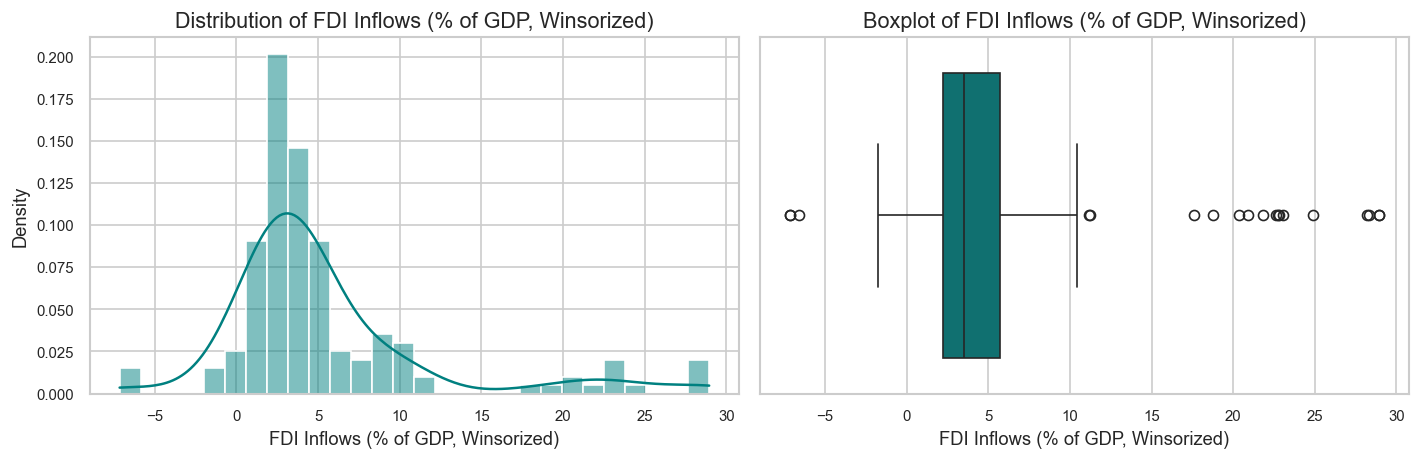

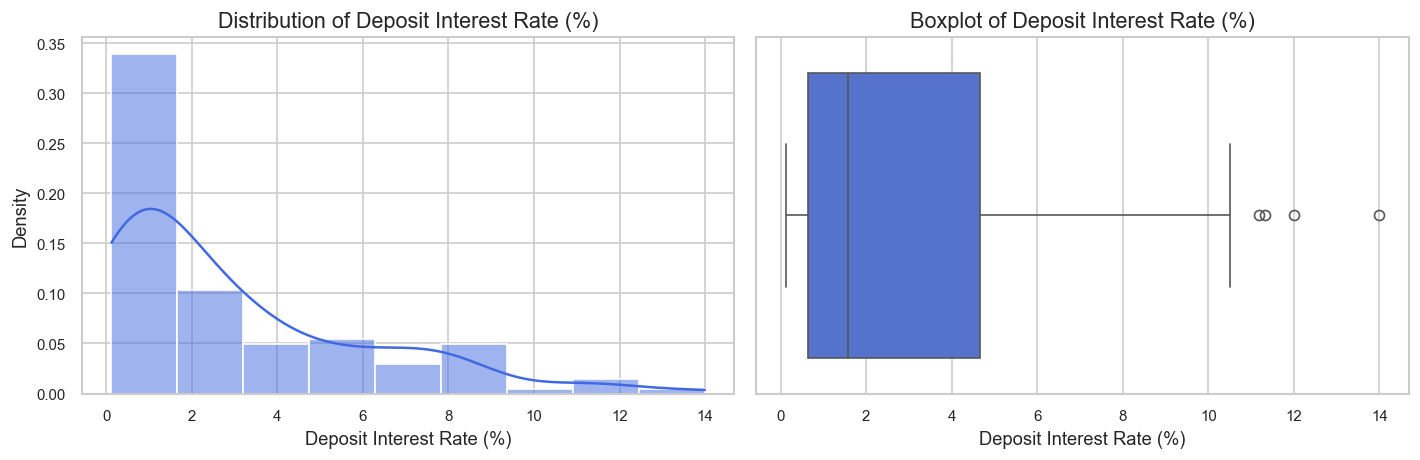

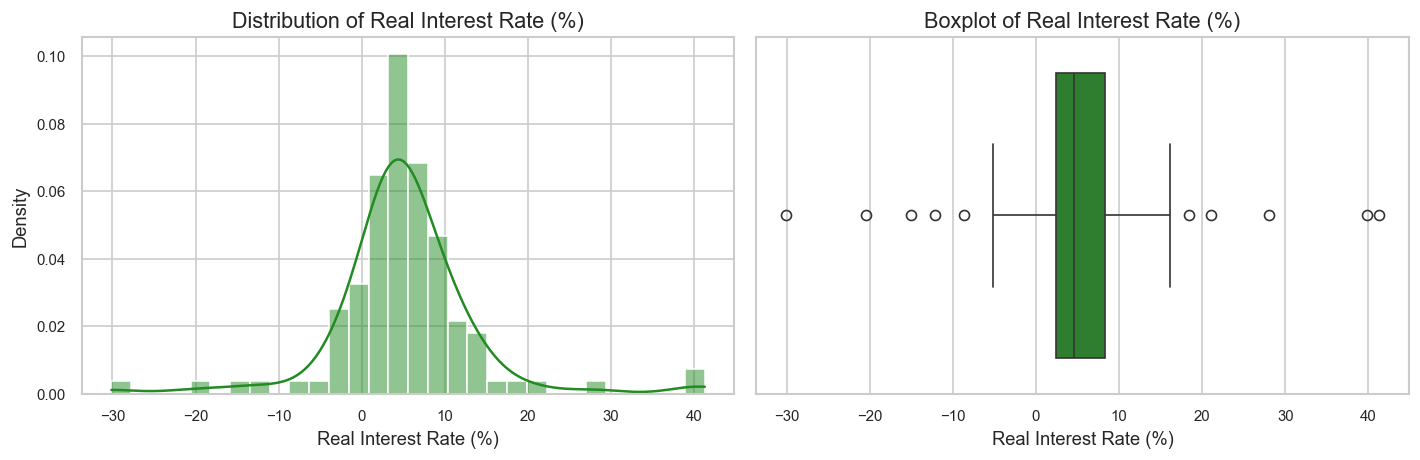

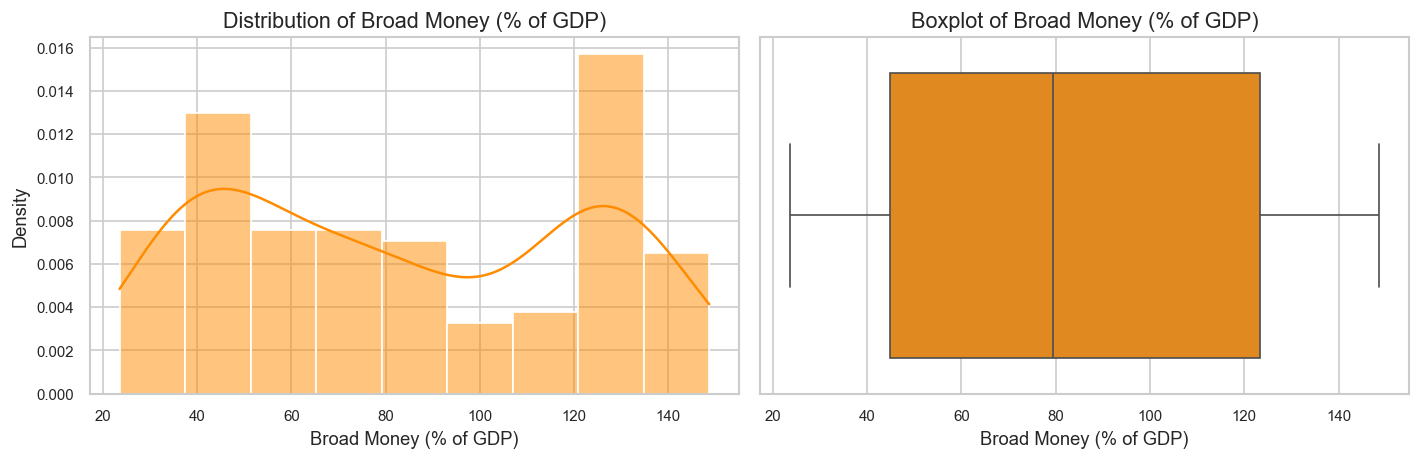

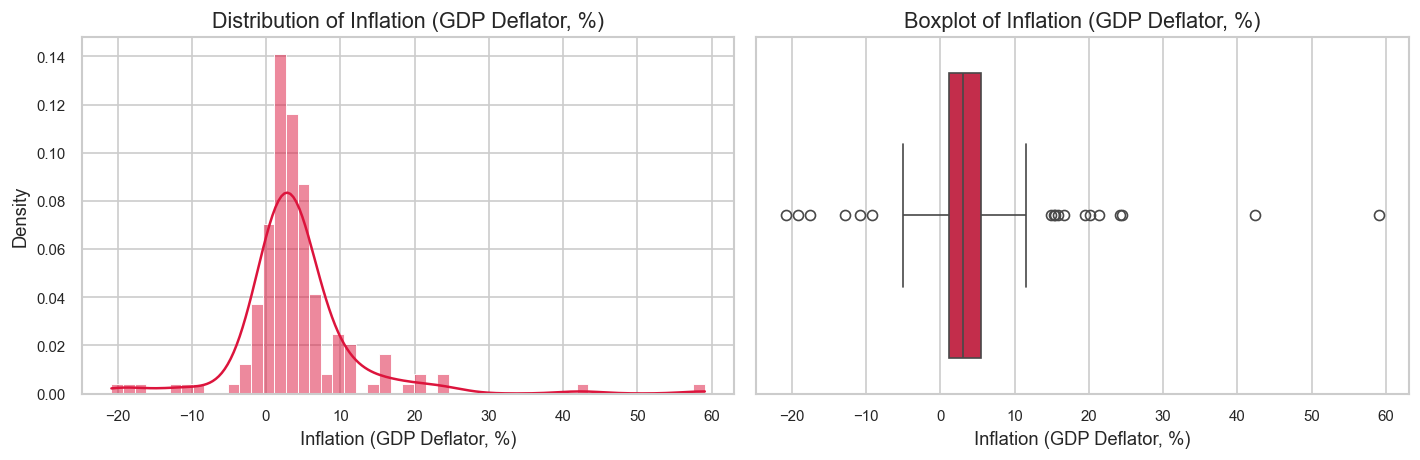

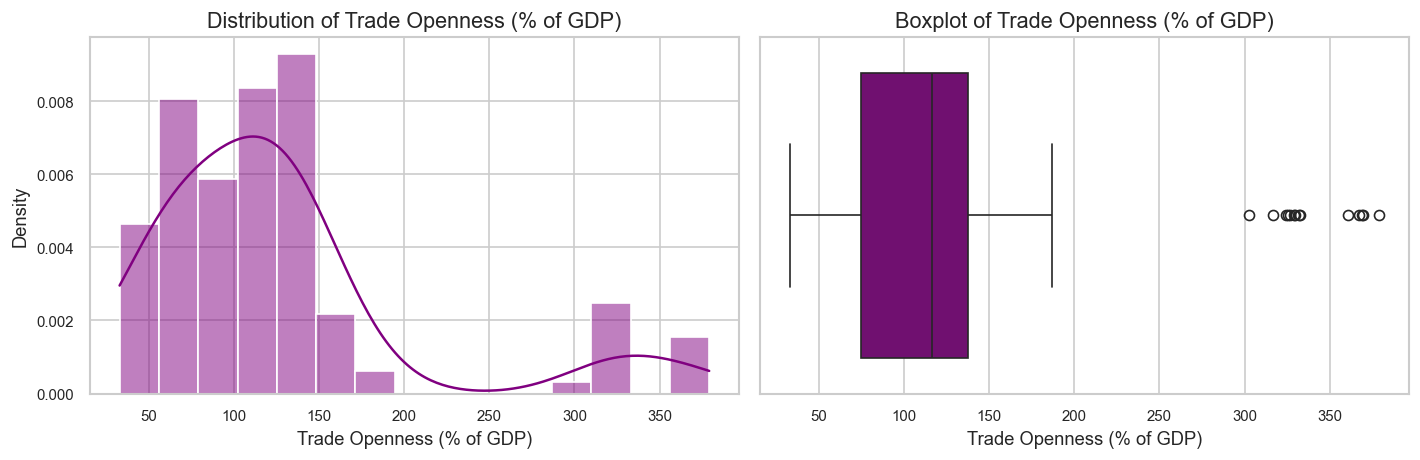

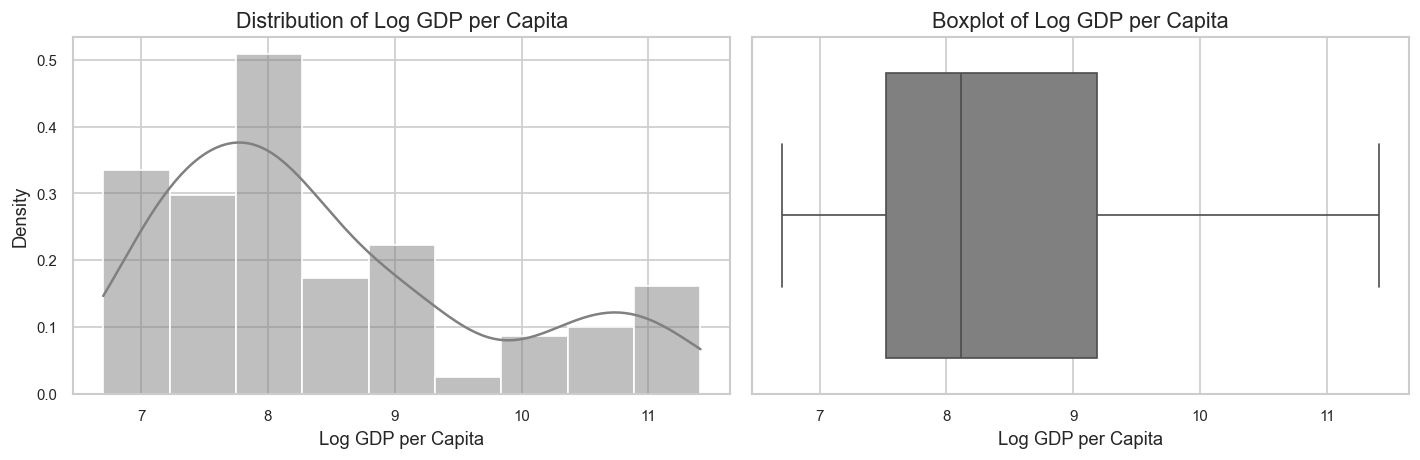

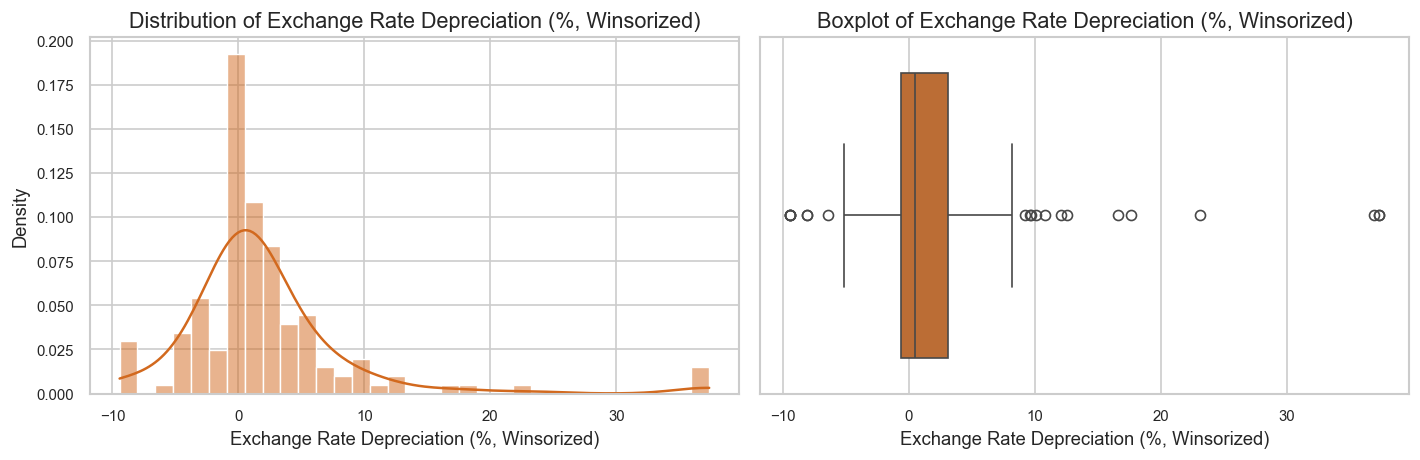

In [4]:
def plot_univariate_distribution(df, col, label, color='skyblue'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    # Hist + KDE
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0], color=color, stat='density')
    axes[0].set_title(f'Distribution of {label}')
    axes[0].set_xlabel(label)
    axes[0].set_ylabel('Density')
    # Boxplot
    sns.boxplot(x=df[col].dropna(), ax=axes[1], color=color)
    axes[1].set_title(f'Boxplot of {label}')
    axes[1].set_xlabel(label)
    plt.tight_layout()
    save_figure(fig, f'univariate_{col}.png', FIGURES_DIR)
    plt.show()

univariate_vars = [
    ('fdi_pct_gdp_winsorized', 'FDI Inflows (% of GDP, Winsorized)', 'teal'),
    ('deposit_interest_rate_pct', 'Deposit Interest Rate (%)', 'royalblue'),
    ('real_interest_rate_pct', 'Real Interest Rate (%)', 'forestgreen'),
    ('broad_money_pct_gdp', 'Broad Money (% of GDP)', 'darkorange'),
    ('inflation_gdp_deflator_pct', 'Inflation (GDP Deflator, %)', 'crimson'),
    ('trade_pct_gdp', 'Trade Openness (% of GDP)', 'purple'),
    ('ln_gdppc', 'Log GDP per Capita', 'grey'),
    ('xr_dep_pct_winsorized', 'Exchange Rate Depreciation (%, Winsorized)', 'chocolate')
]

for col, label, color in univariate_vars:
    if col in df.columns:
        plot_univariate_distribution(df, col, label, color=color)


## 4. Bivariate Analysis

We analyze the bivariate relationships between our dependent variable (`fdi_pct_gdp_winsorized`) and the primary monetary policy proxies and controls using scatter plots with regression fit lines.

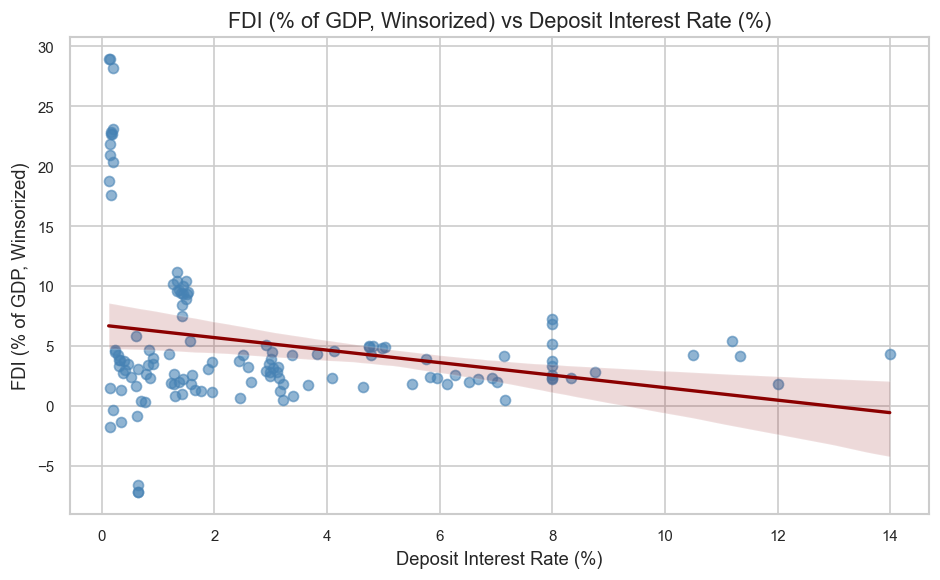

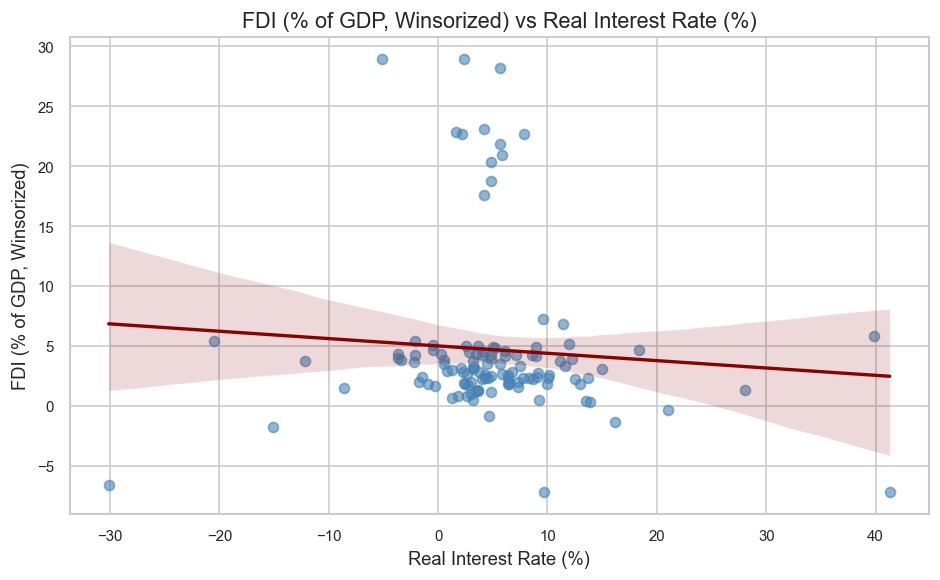

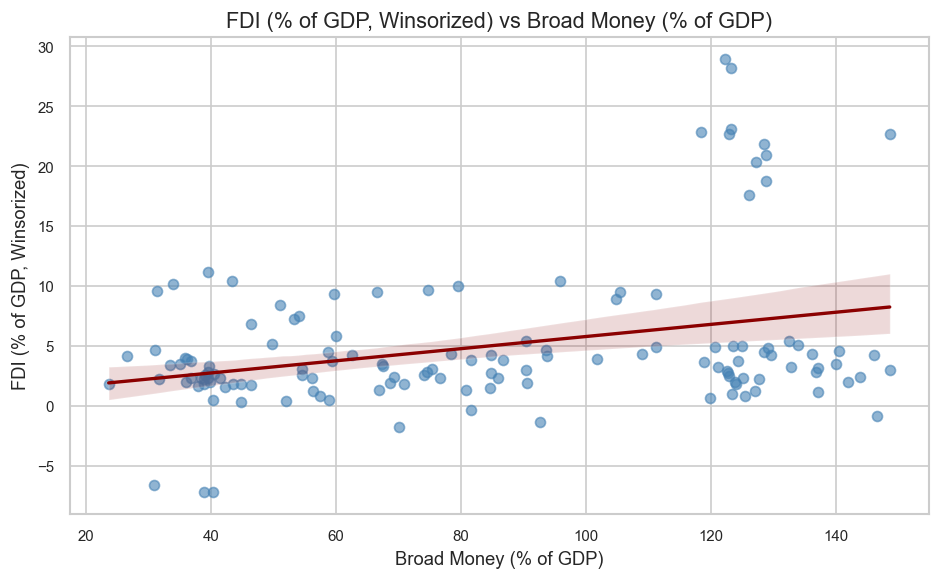

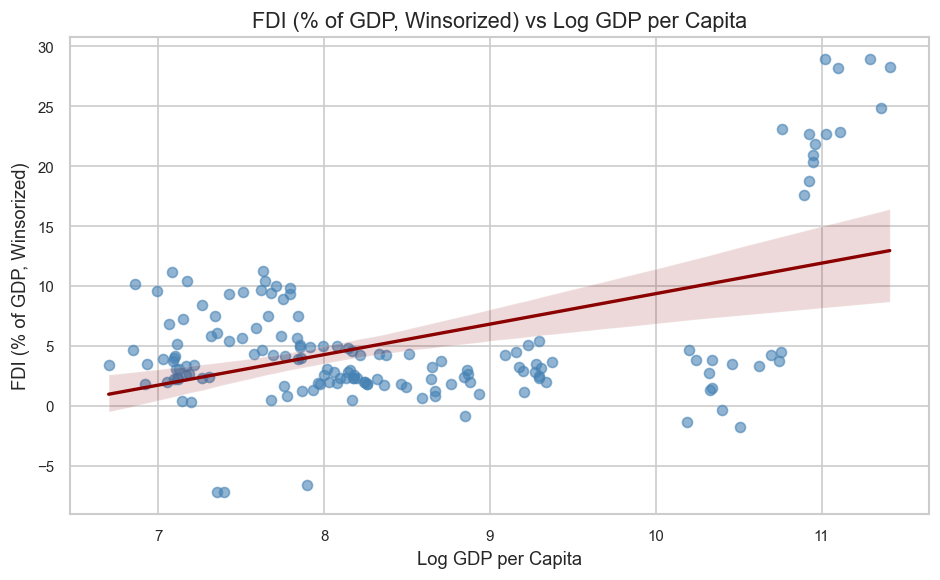

In [5]:
def plot_bivariate_relationship(df, x_col, y_col, x_label, y_label, color='coral'):
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.regplot(data=df, x=x_col, y=y_col, ax=ax, color=color, 
                scatter_kws={'alpha': 0.6}, line_kws={'color': 'darkred', 'lw': 2})
    ax.set_title(f'{y_label} vs {x_label}')
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    plt.tight_layout()
    save_figure(fig, f'bivariate_{x_col}_vs_{y_col}.png', FIGURES_DIR)
    plt.show()

bivariate_pairs = [
    ('deposit_interest_rate_pct', 'deposit_interest_rate_pct', 'Deposit Interest Rate (%)'),
    ('real_interest_rate_pct', 'real_interest_rate_pct', 'Real Interest Rate (%)'),
    ('broad_money_pct_gdp', 'broad_money_pct_gdp', 'Broad Money (% of GDP)'),
    ('ln_gdppc', 'ln_gdppc', 'Log GDP per Capita')
]

for col, _, label in bivariate_pairs:
    if col in df.columns:
        plot_bivariate_relationship(df, col, 'fdi_pct_gdp_winsorized', label, 'FDI (% of GDP, Winsorized)', color='steelblue')


## 5. Winsorization Verification

To handle outliers, we winsorized `fdi_pct_gdp` and `xr_dep_pct` at the 2.5th and 97.5th percentiles. Let's compare their distributions before and after winsorization to verify how extreme values are managed.

In [6]:
winsor_vars = [
    ('fdi_pct_gdp', 'fdi_pct_gdp_winsorized'),
    ('xr_dep_pct', 'xr_dep_pct_winsorized')
]

for raw, winsor in winsor_vars:
    if raw in df.columns and winsor in df.columns:
        display(Markdown(f"### Winsorization Comparison: `{raw}` vs `{winsor}`"))
        comparison = df[[raw, winsor]].describe().T
        display(comparison)

### Winsorization Comparison: `fdi_pct_gdp` vs `fdi_pct_gdp_winsorized`

,count,mean,std,min,25%,50%,75%,max
fdi_pct_gdp,154.0,5.423976,6.824823,-16.205300,2.224864,3.500706,5.691647,32.596461
fdi_pct_gdp_winsorized,154.0,5.458553,6.558654,-7.158034,2.224864,3.500706,5.691647,28.954170


### Winsorization Comparison: `xr_dep_pct` vs `xr_dep_pct_winsorized`

,count,mean,std,min,25%,50%,75%,max
xr_dep_pct,143.0,5.137054,40.232425,-9.430561,-0.618213,0.543346,3.140733,476.795463
xr_dep_pct_winsorized,143.0,2.062091,7.048206,-9.430561,-0.618213,0.543346,3.140733,37.364307


## 6. Correlation Analysis

To examine collinearity and relationships between variables, we compute the Pearson correlation matrix and a pairwise sample size matrix (which indicates the number of active country-year observations for each pair).

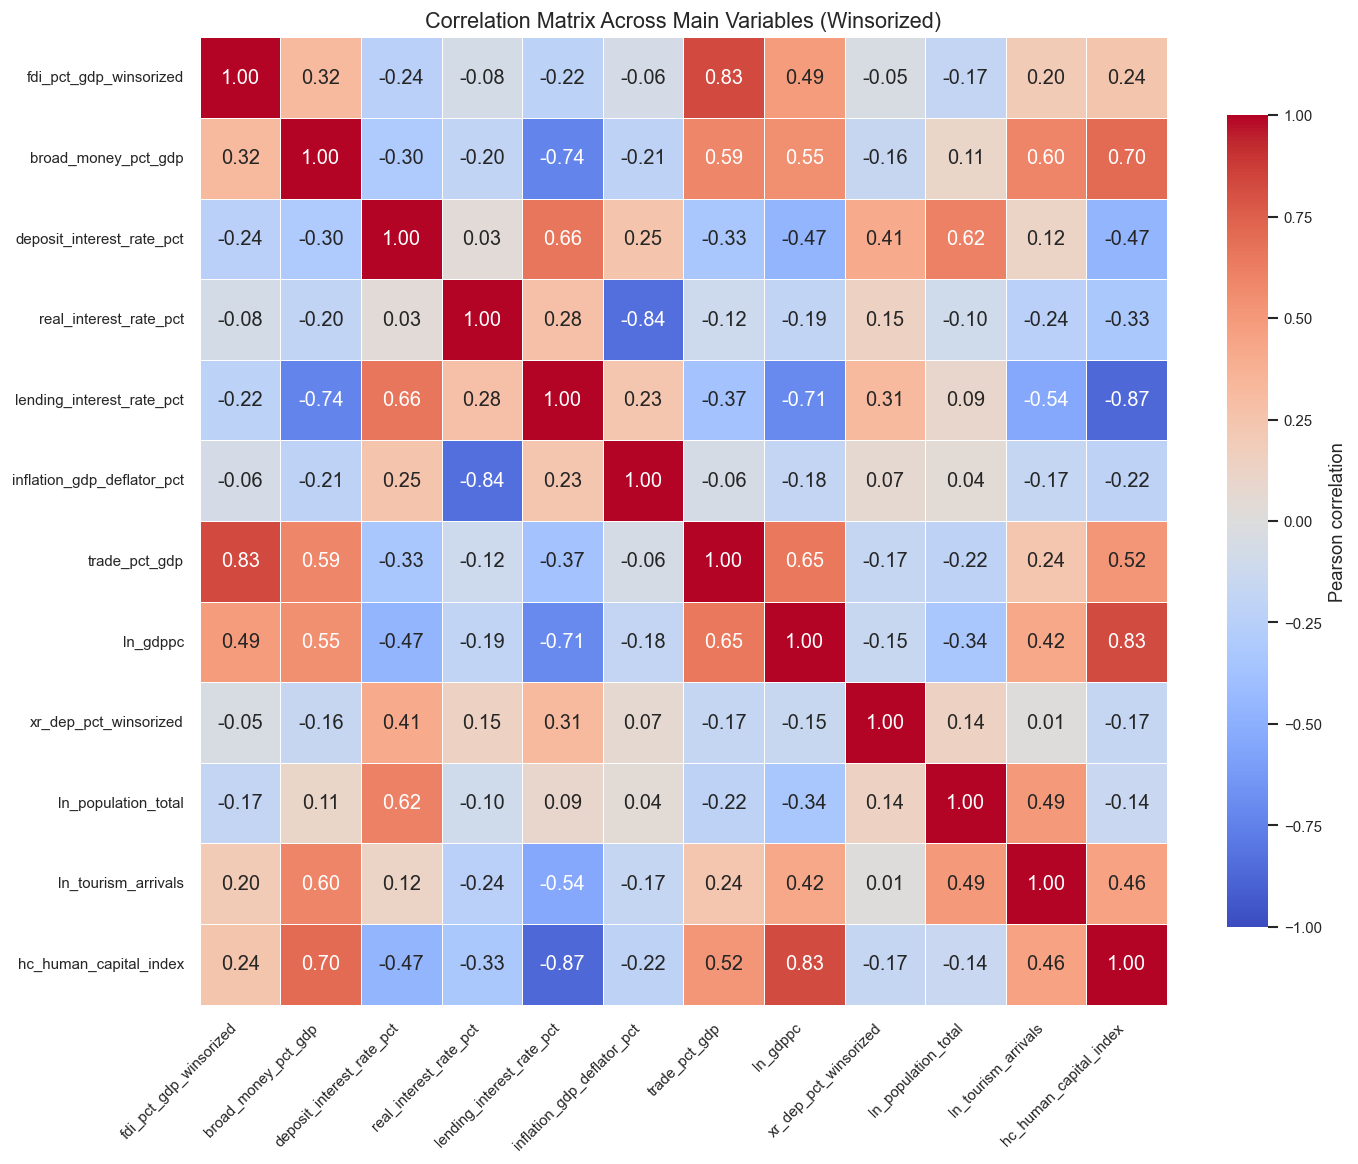

### Pearson Correlation Coefficients

,fdi_pct_gdp_winsorized,broad_money_pct_gdp,deposit_interest_rate_pct,real_interest_rate_pct,lending_interest_rate_pct,inflation_gdp_deflator_pct,trade_pct_gdp,ln_gdppc,xr_dep_pct_winsorized,ln_population_total,ln_tourism_arrivals,hc_human_capital_index
fdi_pct_gdp_winsorized,1.000000,0.315551,-0.241758,-0.077194,-0.222820,-0.064060,0.829727,0.489761,-0.046703,-0.174002,0.198264,0.244969
broad_money_pct_gdp,0.315551,1.000000,-0.300046,-0.195254,-0.738766,-0.213856,0.590904,0.553507,-0.161206,0.106419,0.599953,0.704940
deposit_interest_rate_pct,-0.241758,-0.300046,1.000000,0.033770,0.661464,0.254257,-0.331159,-0.465195,0.409426,0.615226,0.119969,-0.468627
real_interest_rate_pct,-0.077194,-0.195254,0.033770,1.000000,0.279050,-0.837819,-0.116484,-0.191268,0.148027,-0.099482,-0.235483,-0.326599
lending_interest_rate_pct,-0.222820,-0.738766,0.661464,0.279050,1.000000,0.234649,-0.374490,-0.706384,0.312968,0.088975,-0.540518,-0.868241
inflation_gdp_deflator_pct,-0.064060,-0.213856,0.254257,-0.837819,0.234649,1.000000,-0.059795,-0.179041,0.065418,0.040590,-0.166945,-0.215774
trade_pct_gdp,0.829727,0.590904,-0.331159,-0.116484,-0.374490,-0.059795,1.000000,0.653460,-0.170730,-0.216022,0.240102,0.522005
ln_gdppc,0.489761,0.553507,-0.465195,-0.191268,-0.706384,-0.179041,0.653460,1.000000,-0.153728,-0.338026,0.423316,0.826826
xr_dep_pct_winsorized,-0.046703,-0.161206,0.409426,0.148027,0.312968,0.065418,-0.170730,-0.153728,1.000000,0.137080,0.012225,-0.170292
ln_population_total,-0.174002,0.106419,0.615226,-0.099482,0.088975,0.040590,-0.216022,-0.338026,0.137080,1.000000,0.492848,-0.143879


### Pairwise Sample Size (N) Matrix

,fdi_pct_gdp_winsorized,broad_money_pct_gdp,deposit_interest_rate_pct,real_interest_rate_pct,lending_interest_rate_pct,inflation_gdp_deflator_pct,trade_pct_gdp,ln_gdppc,xr_dep_pct_winsorized,ln_population_total,ln_tourism_arrivals,hc_human_capital_index
fdi_pct_gdp_winsorized,154,133,132,117,117,154,140,154,143,154,154,140
broad_money_pct_gdp,133,133,130,115,115,133,122,133,122,133,133,119
deposit_interest_rate_pct,132,130,132,117,117,132,121,132,121,132,132,118
real_interest_rate_pct,117,115,117,117,117,117,106,117,108,117,117,104
lending_interest_rate_pct,117,115,117,117,117,117,106,117,108,117,117,104
inflation_gdp_deflator_pct,154,133,132,117,117,154,140,154,143,154,154,140
trade_pct_gdp,140,122,121,106,106,140,140,140,130,140,140,126
ln_gdppc,154,133,132,117,117,154,140,154,143,154,154,140
xr_dep_pct_winsorized,143,122,121,108,108,143,130,143,143,143,143,130
ln_population_total,154,133,132,117,117,154,140,154,143,154,154,140


In [7]:
analysis_vars = [
    'fdi_pct_gdp_winsorized',
    'broad_money_pct_gdp',
    'deposit_interest_rate_pct',
    'real_interest_rate_pct',
    'lending_interest_rate_pct',
    'inflation_gdp_deflator_pct',
    'trade_pct_gdp',
    'ln_gdppc',
    'xr_dep_pct_winsorized',
    'ln_population_total',
    'ln_tourism_arrivals',
    'hc_human_capital_index'
]

analysis_vars = [v for v in analysis_vars if v in df.columns]

correlation_matrix = df[analysis_vars].corr(method='pearson')
correlation_pairwise_n = pd.DataFrame(
    {
        column: {
            other_column: int(df[[column, other_column]].dropna().shape[0])
            for other_column in analysis_vars
        }
        for column in analysis_vars
    }
).reindex(index=analysis_vars, columns=analysis_vars)

fig, ax = correlation_heatmap(
    correlation_matrix,
    title='Correlation Matrix Across Main Variables (Winsorized)',

)
save_figure(fig, 'correlation_matrix_main_variables.png', FIGURES_DIR)
plt.show()

display(Markdown("### Pearson Correlation Coefficients"))
display(correlation_matrix)

display(Markdown("### Pairwise Sample Size (N) Matrix"))
display(correlation_pairwise_n)

## 7. Country-Year Coverage and Panel Balance

We inspect the panel completeness and country-year availability windows to evaluate the missingness structure.

In [8]:
try:
    coverage_by_variable = pd.read_csv(OUTPUTS_DIR / 'coverage_by_variable.csv', index_col=0)
    coverage_by_country = pd.read_csv(OUTPUTS_DIR / 'coverage_by_country.csv', index_col=0)
    
    display(Markdown("### Coverage by Variable"))
    display(coverage_by_variable)
    
    display(Markdown("### Coverage by Country"))
    display(coverage_by_country)
except Exception:
    cov_vars = [v for v in analysis_vars if v in df.columns]
    cov_var_df = pd.DataFrame({
        'non_null': df[cov_vars].notna().sum(),
        'null_count': df[cov_vars].isna().sum(),
        'coverage_pct': df[cov_vars].notna().mean() * 100
    })
    display(Markdown("### Coverage by Variable (Computed)"))
    display(cov_var_df)
    
    cov_country_df = df.groupby('country')[cov_vars].count()
    display(Markdown("### Non-Null Count by Country (Computed)"))
    display(cov_country_df)

### Coverage by Variable

,non_missing,total,missing,missing_rate
country_id,154,154,0,0.000000
country_code,154,154,0,0.000000
country,154,154,0,0.000000
year,154,154,0,0.000000
fdi_pct_gdp,154,154,0,0.000000
broad_money_pct_gdp,133,154,21,0.136364
trade_pct_gdp,133,154,21,0.136364
population_total,154,154,0,0.000000
inflation_gdp_deflator_pct,154,154,0,0.000000
official_exchange_rate_lcu_usd,151,154,3,0.019481


### Coverage by Country

,fdi_pct_gdp,broad_money_pct_gdp,deposit_interest_rate_pct,real_interest_rate_pct,lending_interest_rate_pct,trade_pct_gdp,inflation_gdp_deflator_pct,ln_gdppc,xr_dep_pct,ln_tourism_arrivals,ln_population_total,hc_human_capital_index
country,,,,,,,,,,,,
Brunei Darussalam,14,14,14,14,14,14,14,14,13,14,14,14
Cambodia,14,14,14,0,0,14,14,14,13,14,14,14
Indonesia,14,14,14,14,14,14,14,14,13,14,14,14
Lao PDR,14,1,1,1,1,14,14,14,13,14,14,14
Malaysia,14,14,14,14,14,14,14,14,13,14,14,14
Myanmar,14,11,11,11,11,0,14,14,13,14,14,14
Philippines,14,13,10,10,10,14,14,14,13,14,14,14
Singapore,14,11,12,12,12,14,14,14,13,14,14,14
Thailand,14,14,14,14,14,14,14,14,13,14,14,14


## 8. Year-Level Visualizations

These figures collapse the panel by year. They help identify macro-level time patterns across the full sample, such as whether FDI, monetary depth, interest rates, trade openness, and exchange-rate depreciation move together over time. The shaded bands show cross-country dispersion where relevant.

### Yearly summary statistics

fdi_pct_gdp_winsorized                     broad_money_pct_gdp          \
                       mean median    std count                mean  median   
year                                                                          
2010                  5.680  3.909  6.279    11              67.412  58.813   
2011                  5.134  4.201  4.776    11              70.051  58.382   
2012                  5.463  3.480  5.153    11              73.118  57.481   
2013                  5.856  4.002  5.505    11              77.149  64.706   
2014                  5.348  3.319  5.841    11              80.195  68.034   
2015                  5.737  3.271  6.070    11              82.662  75.860   
2016                  4.825  4.471  6.008    11              86.302  83.328   
2017                  6.799  3.858  7.978    11              86.614  81.052   
2018                  5.838  3.080  6.137    11              87.003  78.115   
2019                  4.822  2.507  8.729    11              87.318  82.107   
2020                  4.254  2.414  7.486    11             100.703  94.696   
2021                  5.425  3.115  8.726    11              98.115  97.885   
2022                  5.319  2.392  8.060    11              92.645  95.337   
2023                  5.920  2.277  7.213    11              93.480  96.425   

                   deposit_interest_rate_pct         ... trade_pct_gdp        \
         std count                      mean median  ...           std count   
year                                                 ...                       
2010  39.355    11                     3.899  2.502  ...        90.173    10   
2011  42.299    10                     4.376  2.684  ...        92.256    10   
2012  41.643    10                     3.579  2.790  ...        88.810    10   
2013  41.353    10                     3.114  2.047  ...        89.697    10   
2014  39.694    10                     3.126  1.586  ...        87.639    10   
2015  37.862    10                     2.994  1.513  ...        81.724    10   
2016  36.896    10                     2.885  1.517  ...        75.005    10   
2017  33.900    10                     2.810  1.702  ...        79.390    10   
2018  33.221    10                     2.890  2.246  ...        80.779    10   
2019  35.717    10                     3.079  2.209  ...        80.207    10   
2020  41.191    10                     2.287  1.488  ...        83.056    10   
2021  43.991     8                     1.413  1.019  ...        81.561    10   
2022  40.231     8                     1.676  1.496  ...        80.623    10   
2023  38.653     6                     2.249  1.512  ...        78.901    10   

     xr_dep_pct_winsorized                      ln_gdppc                      
                      mean median     std count     mean median    std count  
year                                                                          
2010                   NaN    NaN     NaN     0    8.134  7.679  1.432    11  
2011                -2.938 -3.584   4.782    11    8.287  7.777  1.446    11  
2012                 3.981  0.000  11.325    11    8.347  7.869  1.423    11  
2013                 4.362  0.130  11.467    11    8.396  7.931  1.379    11  
2014                 3.468  2.636   3.618    11    8.421  7.961  1.345    11  
2015                 6.806  5.300   6.338    11    8.387  7.976  1.275    11  
2016                 1.866  0.488   2.528    11    8.412  8.001  1.237    11  
2017                 1.728  0.543   3.618    11    8.462  8.019  1.250    11  
2018                 0.228  0.014   4.028    11    8.523  8.078  1.278    11  
2019                 0.916  1.128   2.642    11    8.585  8.143  1.224    11  
2020                -0.053  0.789   3.740    11    8.544  8.170  1.183    11  
2021                -0.887 -0.747   3.921    11    8.642  8.217  1.237    11  
2022                 5.664  2.585  11.631    11    8.663  8.330  1.311    11  
2023                 1.665  0.210   

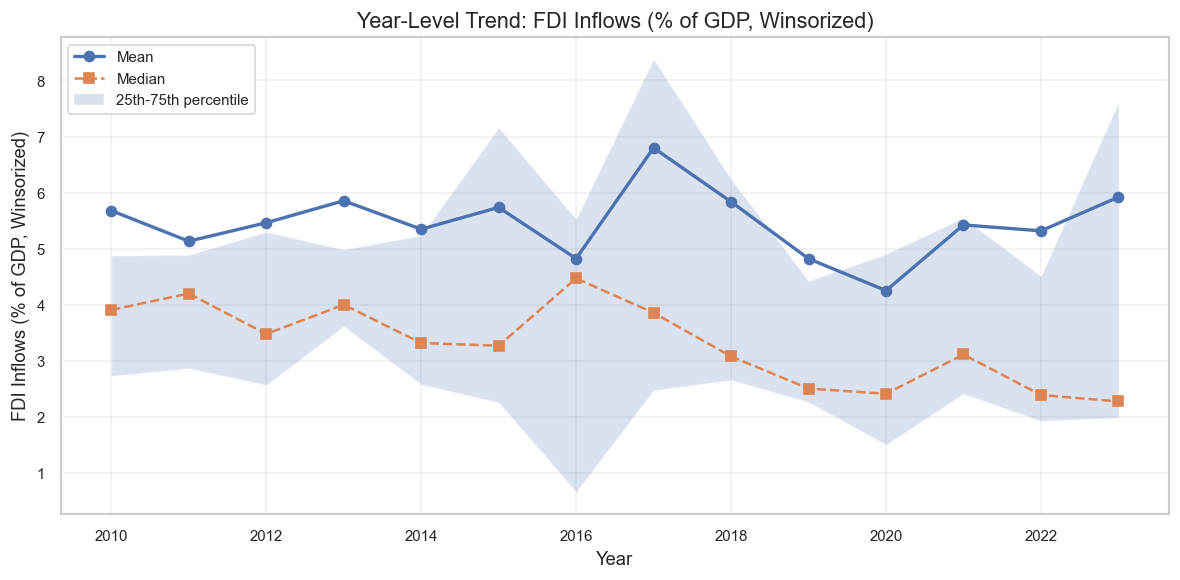

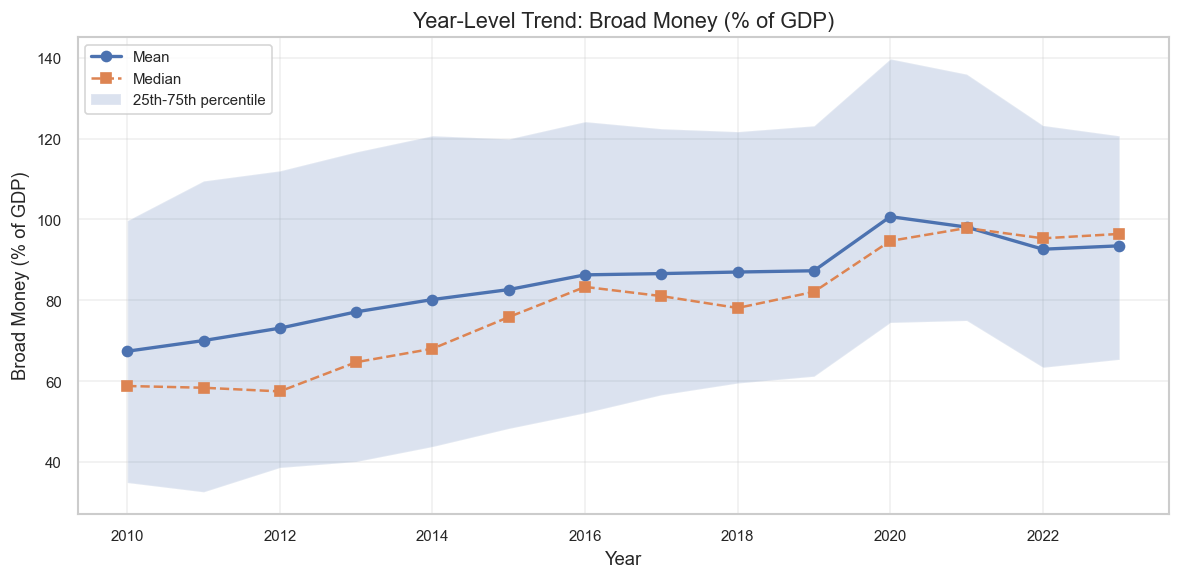

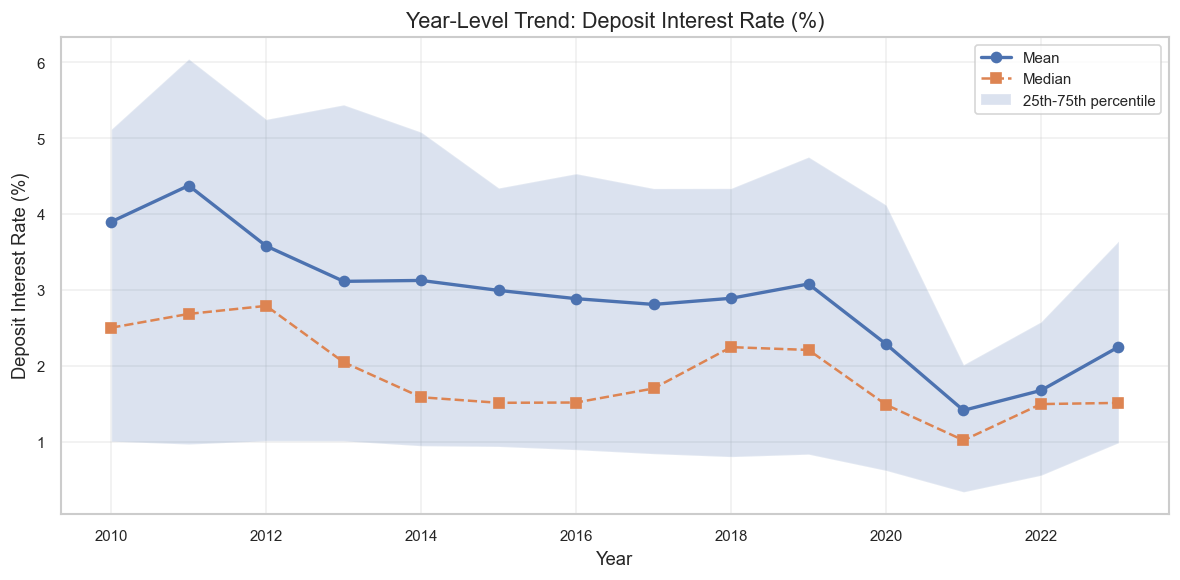

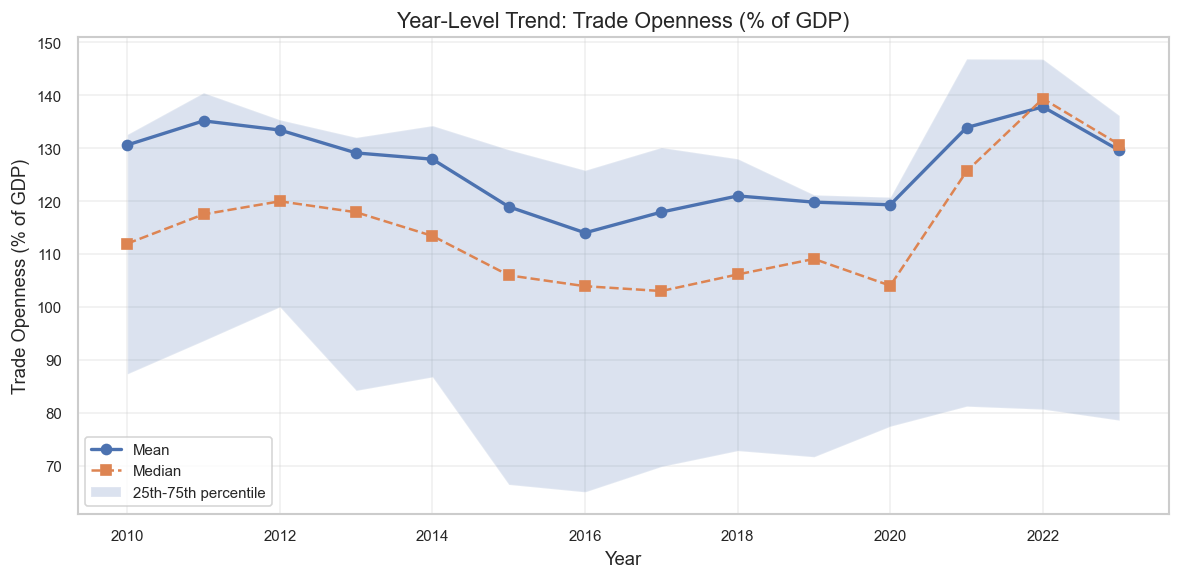

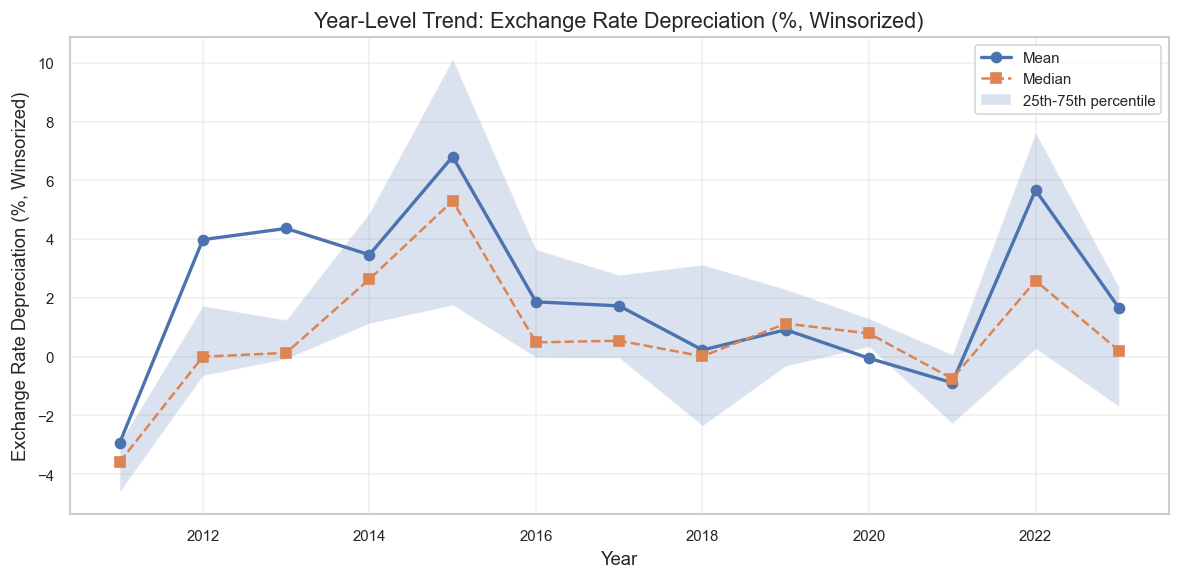

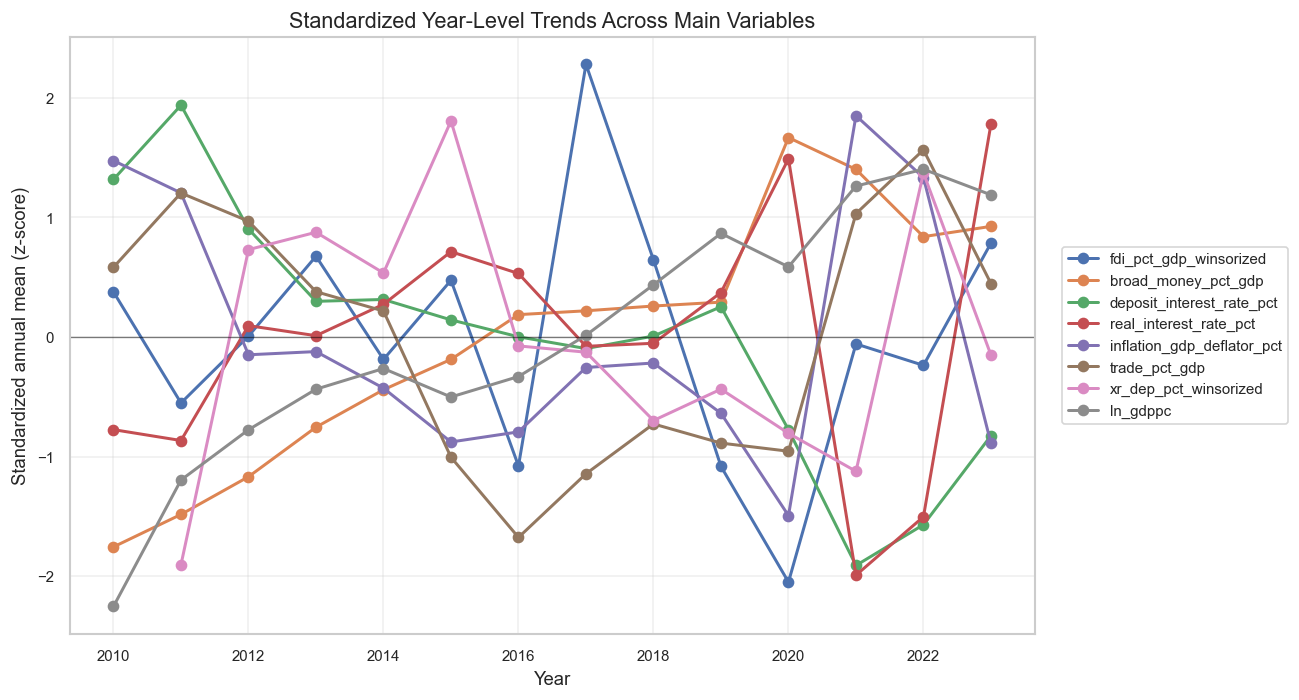

In [9]:

# -----------------------------
# Year-level visualizations
# -----------------------------
year_summary_vars = [
    'fdi_pct_gdp_winsorized',
    'broad_money_pct_gdp',
    'deposit_interest_rate_pct',
    'real_interest_rate_pct',
    'inflation_gdp_deflator_pct',
    'trade_pct_gdp',
    'xr_dep_pct_winsorized',
    'ln_gdppc'
]
year_summary_vars = [v for v in year_summary_vars if v in df.columns]

yearly_summary = (
    df.groupby('year')[year_summary_vars]
      .agg(['mean', 'median', 'std', 'count'])
      .sort_index()
)
display(Markdown("### Yearly summary statistics"))
display(yearly_summary.round(3))

def plot_yearly_mean_with_dispersion(df, var, label, filename):
    yearly = (
        df.groupby('year')[var]
          .agg(mean='mean', median='median', p25=lambda x: x.quantile(0.25), p75=lambda x: x.quantile(0.75), count='count')
          .reset_index()
          .dropna(subset=['mean'])
    )
    if yearly.empty:
        return

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(yearly['year'], yearly['mean'], marker='o', linewidth=2, label='Mean')
    ax.plot(yearly['year'], yearly['median'], marker='s', linewidth=1.5, linestyle='--', label='Median')
    ax.fill_between(yearly['year'], yearly['p25'], yearly['p75'], alpha=0.20, label='25th-75th percentile')
    ax.set_title(f'Year-Level Trend: {label}')
    ax.set_xlabel('Year')
    ax.set_ylabel(label)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    save_figure(fig, filename, FIGURES_DIR)
    plt.show()

year_level_plots = [
    ('fdi_pct_gdp_winsorized', 'FDI Inflows (% of GDP, Winsorized)', 'yearly_fdi_trend.png'),
    ('broad_money_pct_gdp', 'Broad Money (% of GDP)', 'yearly_broad_money_trend.png'),
    ('deposit_interest_rate_pct', 'Deposit Interest Rate (%)', 'yearly_deposit_interest_trend.png'),
    ('trade_pct_gdp', 'Trade Openness (% of GDP)', 'yearly_trade_openness_trend.png'),
    ('xr_dep_pct_winsorized', 'Exchange Rate Depreciation (%, Winsorized)', 'yearly_exchange_rate_depreciation_trend.png')
]

for var, label, filename in year_level_plots:
    if var in df.columns:
        plot_yearly_mean_with_dispersion(df, var, label, filename)

# Compact year-level comparison using standardized annual means
standardized_year_vars = [v for v in year_summary_vars if df[v].notna().sum() > 1]
yearly_means = df.groupby('year')[standardized_year_vars].mean()
yearly_means_z = (yearly_means - yearly_means.mean()) / yearly_means.std(ddof=0)
yearly_means_z = yearly_means_z.dropna(axis=1, how='all')

if not yearly_means_z.empty:
    fig, ax = plt.subplots(figsize=(11, 6))
    yearly_means_z.plot(ax=ax, marker='o', linewidth=1.8)
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    ax.set_title('Standardized Year-Level Trends Across Main Variables')
    ax.set_xlabel('Year')
    ax.set_ylabel('Standardized annual mean (z-score)')
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    save_figure(fig, 'yearly_standardized_variable_trends.png', FIGURES_DIR)
    plt.show()


## 9. Country-Level Visualizations

These figures collapse the panel by country. They show cross-country differences in average FDI, monetary policy conditions, volatility, and data completeness. This is useful for identifying influential countries and interpreting whether results are driven by a small number of high-FDI or high-volatility economies.

### Country-level summary statistics

fdi_pct_gdp_winsorized                       \
                                                 mean  median    std count   
country_code country                                                         
BRN          Brunei Darussalam                  2.424   3.432  2.189    14   
IDN          Indonesia                          1.993   2.022  0.548    14   
KHM          Cambodia                           9.571   9.548  0.899    14   
LAO          Lao PDR                            6.221   5.786  2.219    14   
MMR          Myanmar                            3.523   2.860  1.768    14   
MYS          Malaysia                           3.328   3.206  1.184    14   
PHL          Philippines                        1.992   1.986  0.799    14   
SGP          Singapore                         23.578  22.778  3.777    14   
THA          Thailand                           2.031   2.113  1.382    14   
TLS          Timor-Leste                        0.796   2.523  4.464    14   
VNM          Viet Nam                           4.587   4.444  0.428    14   

                               broad_money_pct_gdp                         \
                                              mean   median     std count   
country_code country                                                        
BRN          Brunei Darussalam              76.546   81.192  11.996    14   
IDN          Indonesia                      40.273   39.474   2.947    14   
KHM          Cambodia                       67.908   63.146  27.821    14   
LAO          Lao PDR                        36.188   36.188     NaN     1   
MMR          Myanmar                        44.302   46.413  14.024    11   
MYS          Malaysia                      130.135  131.096   6.625    14   
PHL          Philippines                    72.779   74.057  11.475    13   
SGP          Singapore                     127.128  126.181   7.857    11   
THA          Thailand                      128.988  124.883  11.641    14   
TLS          Timor-Leste                    41.151   39.550   8.840    14   
VNM          Viet Nam                      113.970  120.640  22.296    13   

                               deposit_interest_rate_pct         ...  \
                                                    mean median  ...   
country_code country                                             ...   
BRN          Brunei Darussalam                     0.290  0.306  ...   
IDN          Indonesia                             6.197  6.391  ...   
KHM          Cambodia                              1.413  1.419  ...   
LAO          Lao PDR                               3.000  3.000  ...   
MMR          Myanmar                               8.470  8.000  ...   
MYS          Malaysia                              2.696  2.947  ...   
PHL          Philippines                           2.492  2.498  ...   
SGP          Singapore                             0.163  0.162  ...   
THA          Thailand                              1.434  1.337  ...   
TLS          Timor-Leste                           0.738  0.727  ...   
VNM          Viet Nam                              6.356  4.892  ...   

                               ln_population_total       ln_tourism_arrivals  \
                                               std count                mean   
country_code country                                                           
BRN          Brunei Darussalam               0.050    14              14.878   
IDN          Indonesia                       0.043    14              15.891   
KHM          Cambodia                        0.059    14              14.950   
LAO          Lao PDR                         0.062    14              14.725   
MMR          Myanmar                         0.032    14              14.361   
MYS          Malaysia                        0.067    14              16.555   
PHL          Philippines                     0.057    14              15.116   
SGP          Singapore                       0.041

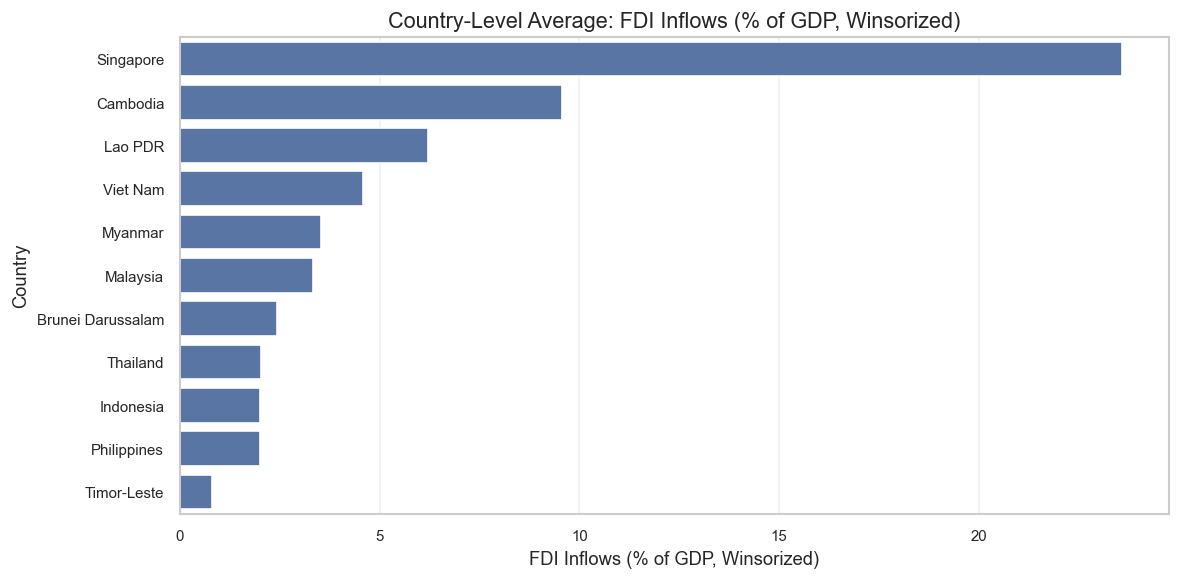

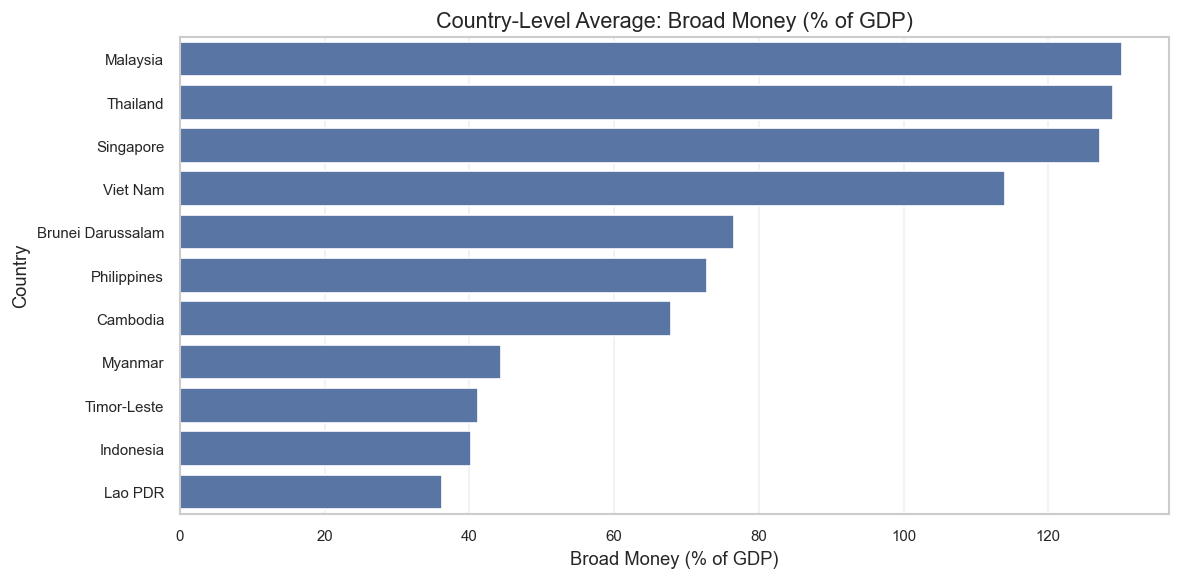

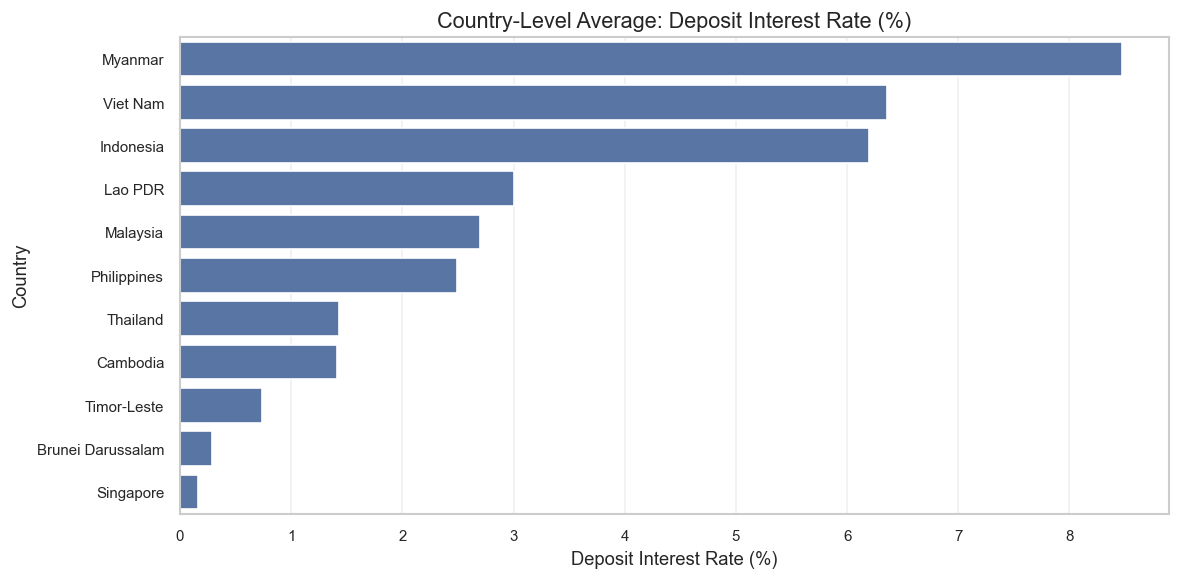

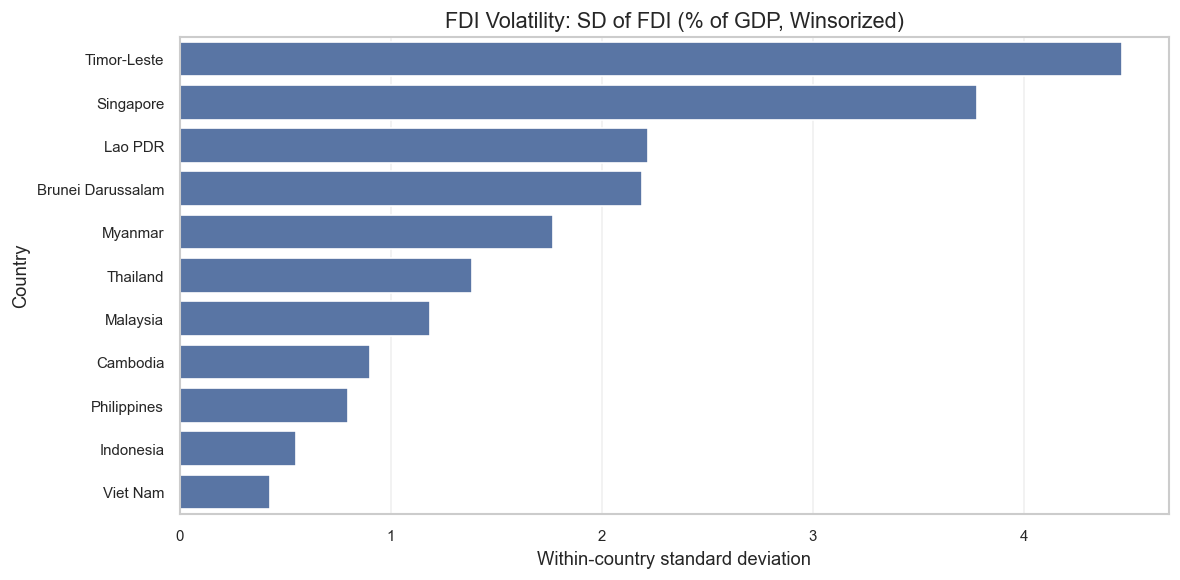

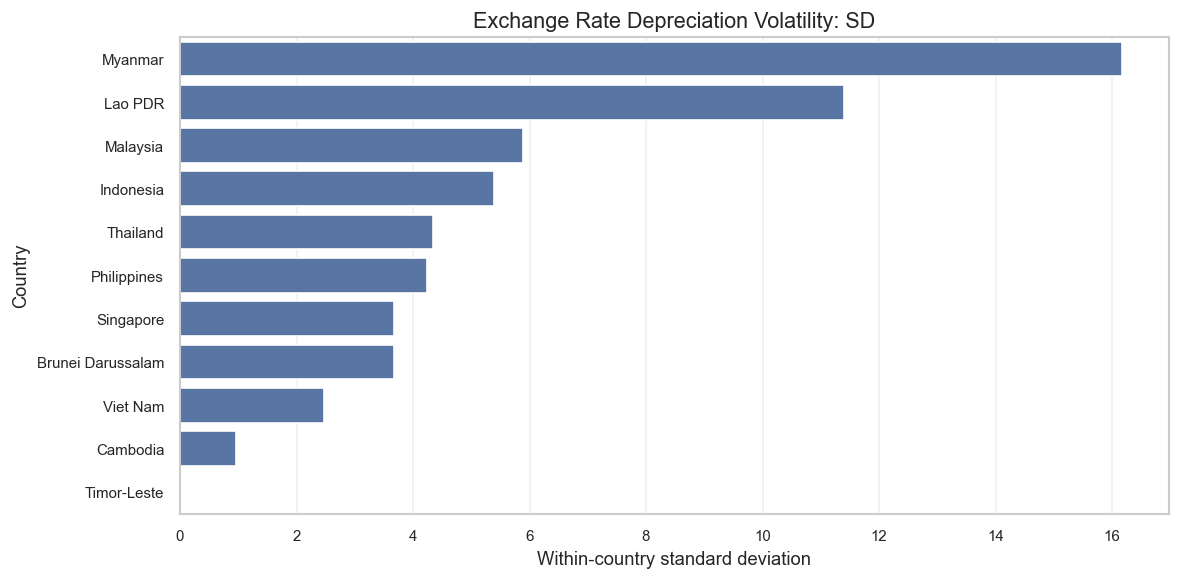

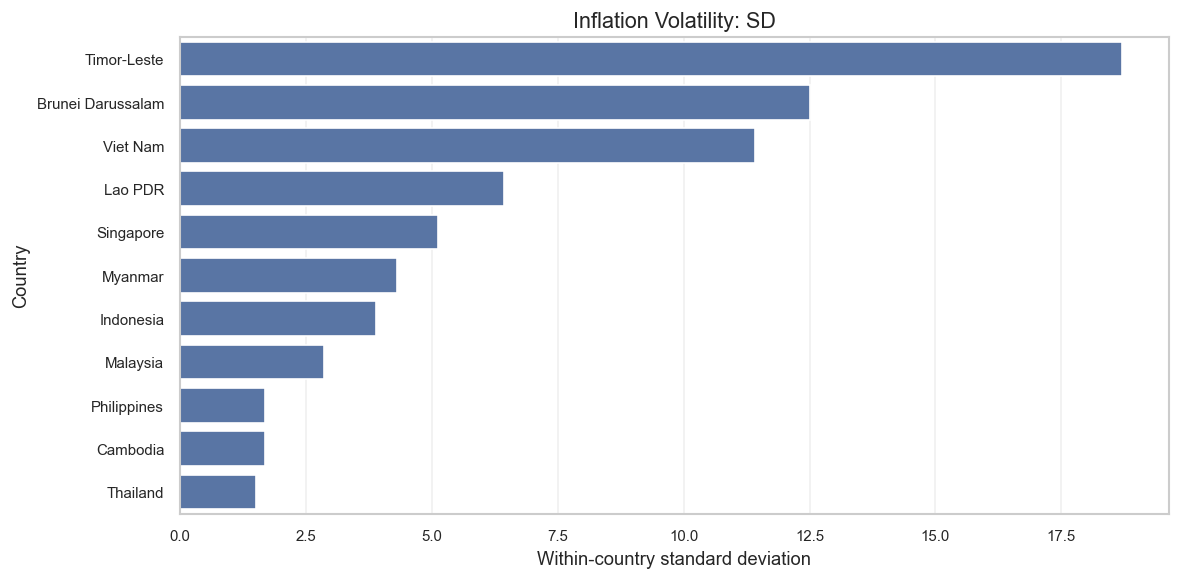

### Average country-level data coverage across selected variables

,Average coverage across selected variables (%)
country,
Brunei Darussalam,99.35
Indonesia,99.35
Malaysia,99.35
Thailand,99.35
Viet Nam,98.70
Singapore,94.81
Philippines,93.51
Cambodia,90.26
Timor-Leste,89.61


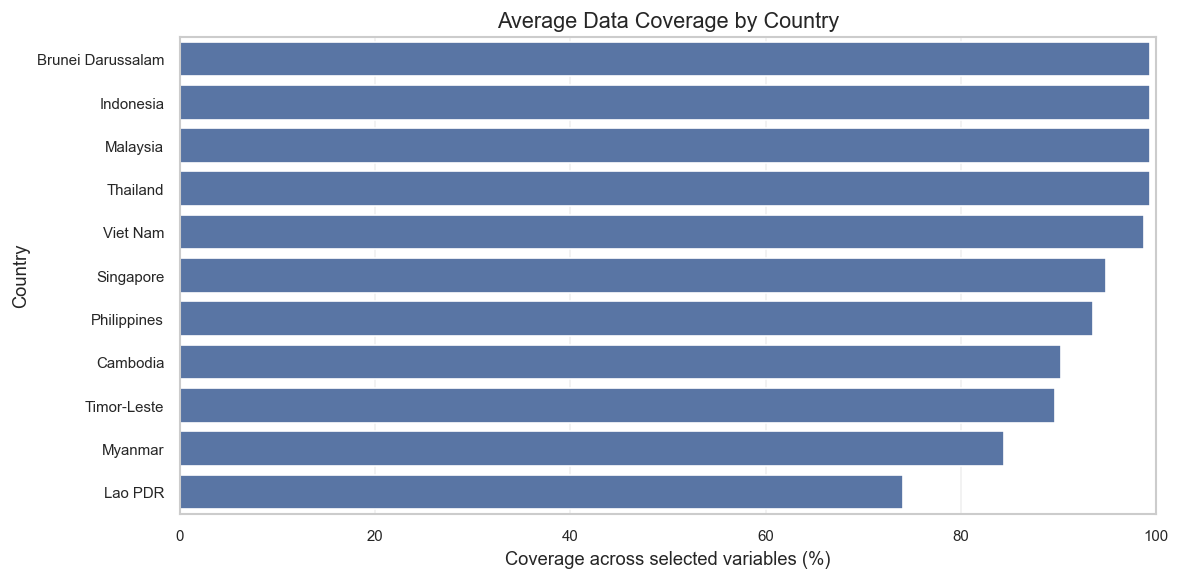

In [10]:

# -----------------------------
# Country-level visualizations
# -----------------------------
country_summary_vars = [
    'fdi_pct_gdp_winsorized',
    'broad_money_pct_gdp',
    'deposit_interest_rate_pct',
    'real_interest_rate_pct',
    'inflation_gdp_deflator_pct',
    'trade_pct_gdp',
    'xr_dep_pct_winsorized',
    'ln_gdppc',
    'ln_population_total',
    'ln_tourism_arrivals',
    'hc_human_capital_index'
]
country_summary_vars = [v for v in country_summary_vars if v in df.columns]

country_summary = (
    df.groupby(['country_code', 'country'])[country_summary_vars]
      .agg(['mean', 'median', 'std', 'count'])
      .sort_index()
)
display(Markdown("### Country-level summary statistics"))
display(country_summary.round(3))

def country_barplot(df, var, label, filename, top_n=None, ascending=False):
    country_means = (
        df.groupby('country')[var]
          .mean()
          .dropna()
          .sort_values(ascending=ascending)
    )
    if top_n is not None:
        country_means = country_means.head(top_n)
    if country_means.empty:
        return

    fig_height = max(5, 0.35 * len(country_means))
    fig, ax = plt.subplots(figsize=(10, fig_height))
    sns.barplot(x=country_means.values, y=country_means.index, ax=ax, orient='h')
    ax.set_title(f'Country-Level Average: {label}')
    ax.set_xlabel(label)
    ax.set_ylabel('Country')
    ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    save_figure(fig, filename, FIGURES_DIR)
    plt.show()

country_barplot(df, 'fdi_pct_gdp_winsorized', 'FDI Inflows (% of GDP, Winsorized)', 'country_average_fdi.png')
country_barplot(df, 'broad_money_pct_gdp', 'Broad Money (% of GDP)', 'country_average_broad_money.png')
country_barplot(df, 'deposit_interest_rate_pct', 'Deposit Interest Rate (%)', 'country_average_deposit_interest_rate.png')

# Volatility / instability indicators by country
volatility_vars = [
    ('fdi_pct_gdp_winsorized', 'FDI Volatility: SD of FDI (% of GDP, Winsorized)', 'country_fdi_volatility.png'),
    ('xr_dep_pct_winsorized', 'Exchange Rate Depreciation Volatility: SD', 'country_xr_dep_volatility.png'),
    ('inflation_gdp_deflator_pct', 'Inflation Volatility: SD', 'country_inflation_volatility.png')
]
for var, label, filename in volatility_vars:
    if var in df.columns:
        country_vol = df.groupby('country')[var].std().dropna().sort_values(ascending=False)
        if not country_vol.empty:
            fig_height = max(5, 0.35 * len(country_vol))
            fig, ax = plt.subplots(figsize=(10, fig_height))
            sns.barplot(x=country_vol.values, y=country_vol.index, ax=ax, orient='h')
            ax.set_title(label)
            ax.set_xlabel('Within-country standard deviation')
            ax.set_ylabel('Country')
            ax.grid(True, axis='x', alpha=0.3)
            plt.tight_layout()
            save_figure(fig, filename, FIGURES_DIR)
            plt.show()

# Country-level data completeness across main analysis variables
if country_summary_vars:
    country_completeness = (
        df.groupby('country')[country_summary_vars]
          .apply(lambda x: x.notna().mean().mean() * 100)
          .sort_values(ascending=False)
          .rename('Average coverage across selected variables (%)')
    )
    display(Markdown("### Average country-level data coverage across selected variables"))
    display(country_completeness.to_frame().round(2))

    fig, ax = plt.subplots(figsize=(10, max(5, 0.35 * len(country_completeness))))
    sns.barplot(x=country_completeness.values, y=country_completeness.index, ax=ax, orient='h')
    ax.set_title('Average Data Coverage by Country')
    ax.set_xlabel('Coverage across selected variables (%)')
    ax.set_ylabel('Country')
    ax.set_xlim(0, 100)
    ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    save_figure(fig, 'country_average_data_coverage.png', FIGURES_DIR)
    plt.show()


## 10. Year-Country Visualizations

These figures retain the panel structure. Heatmaps and small multiples make it easier to see where country-specific changes occur over time, whether missingness is concentrated in specific periods, and whether each country follows the pooled trend or a distinct trajectory.

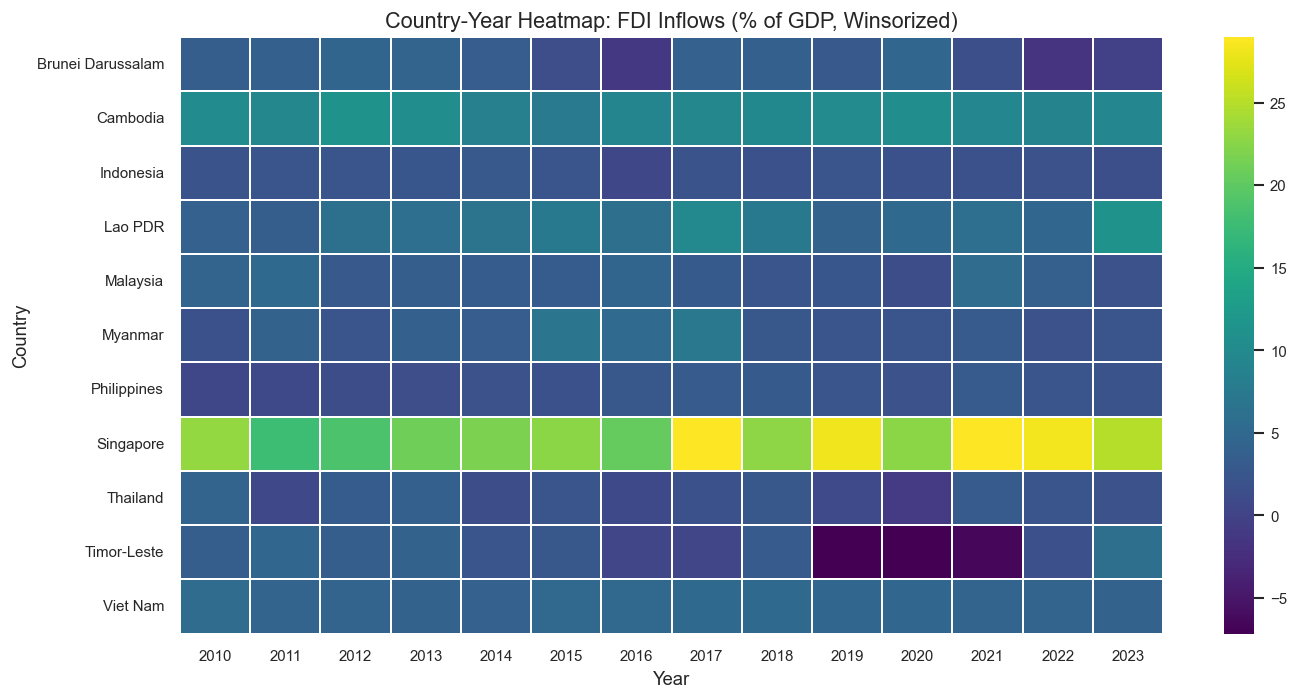

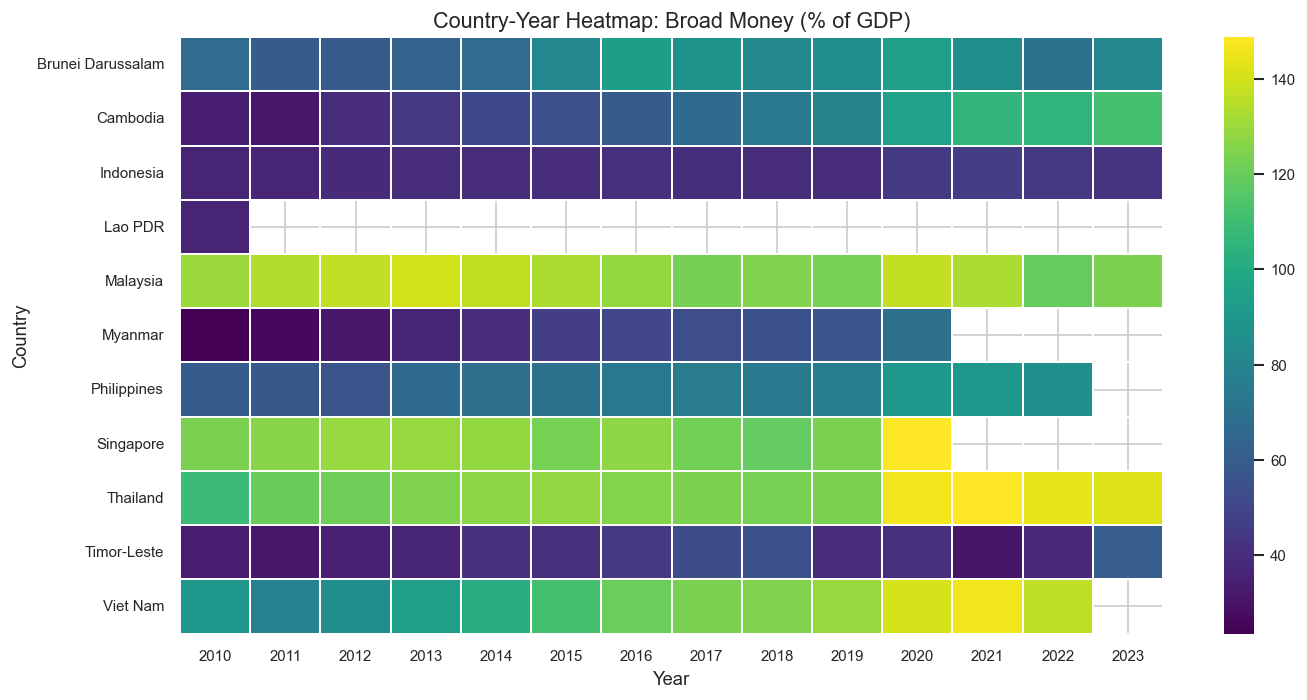

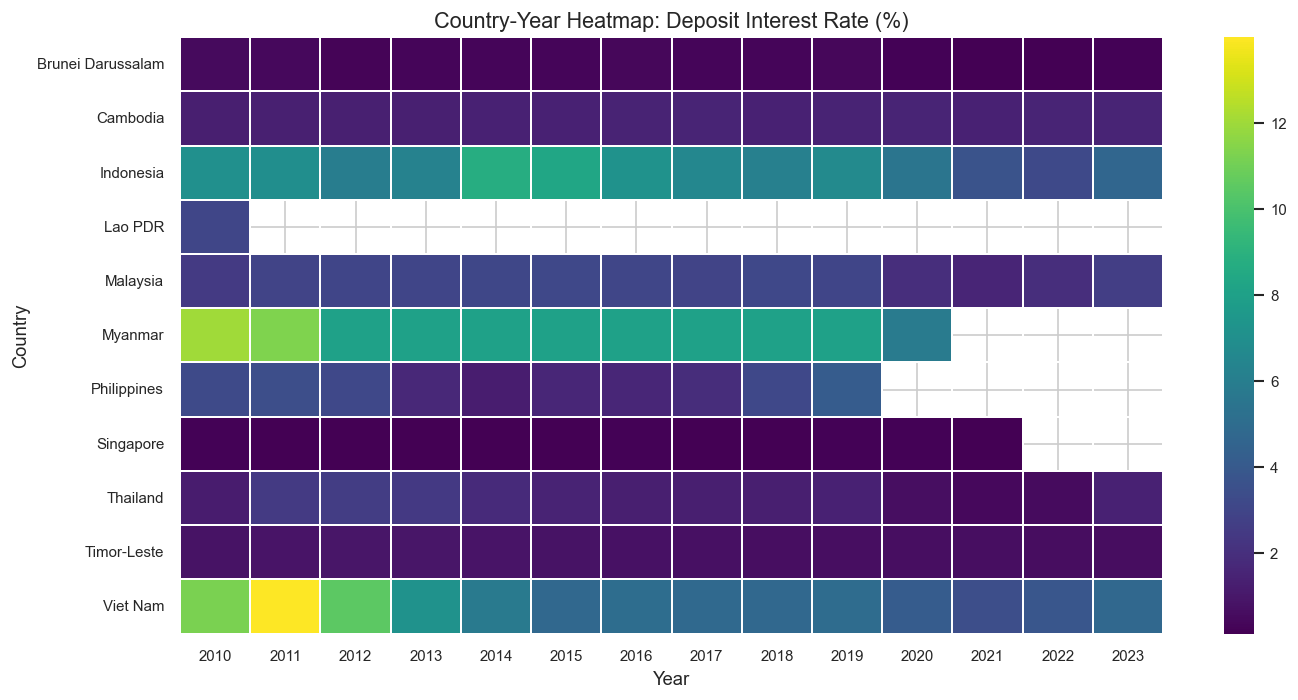

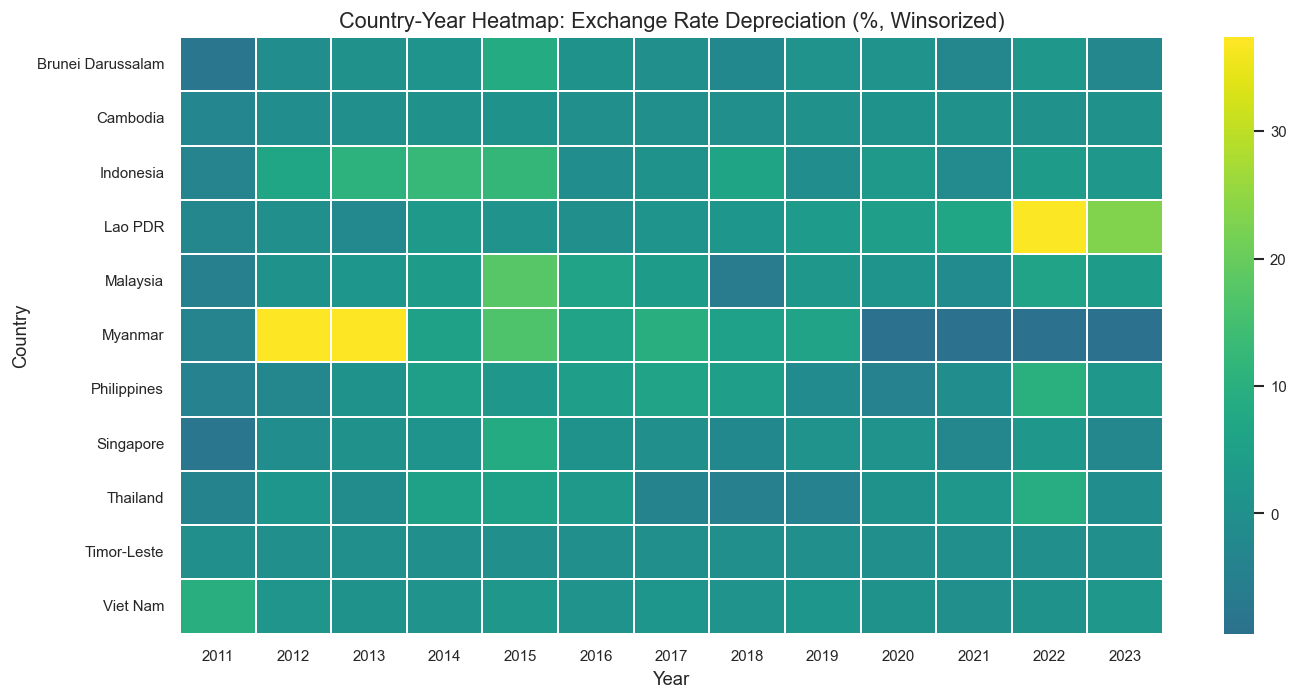

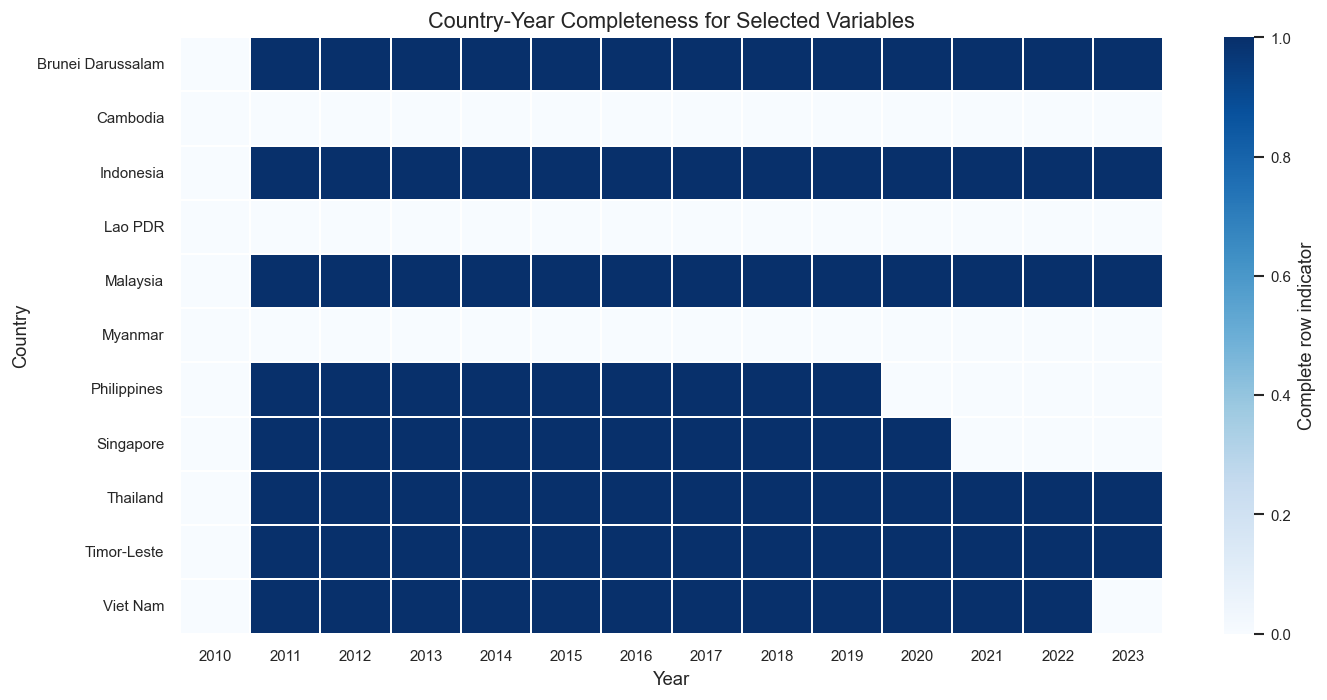

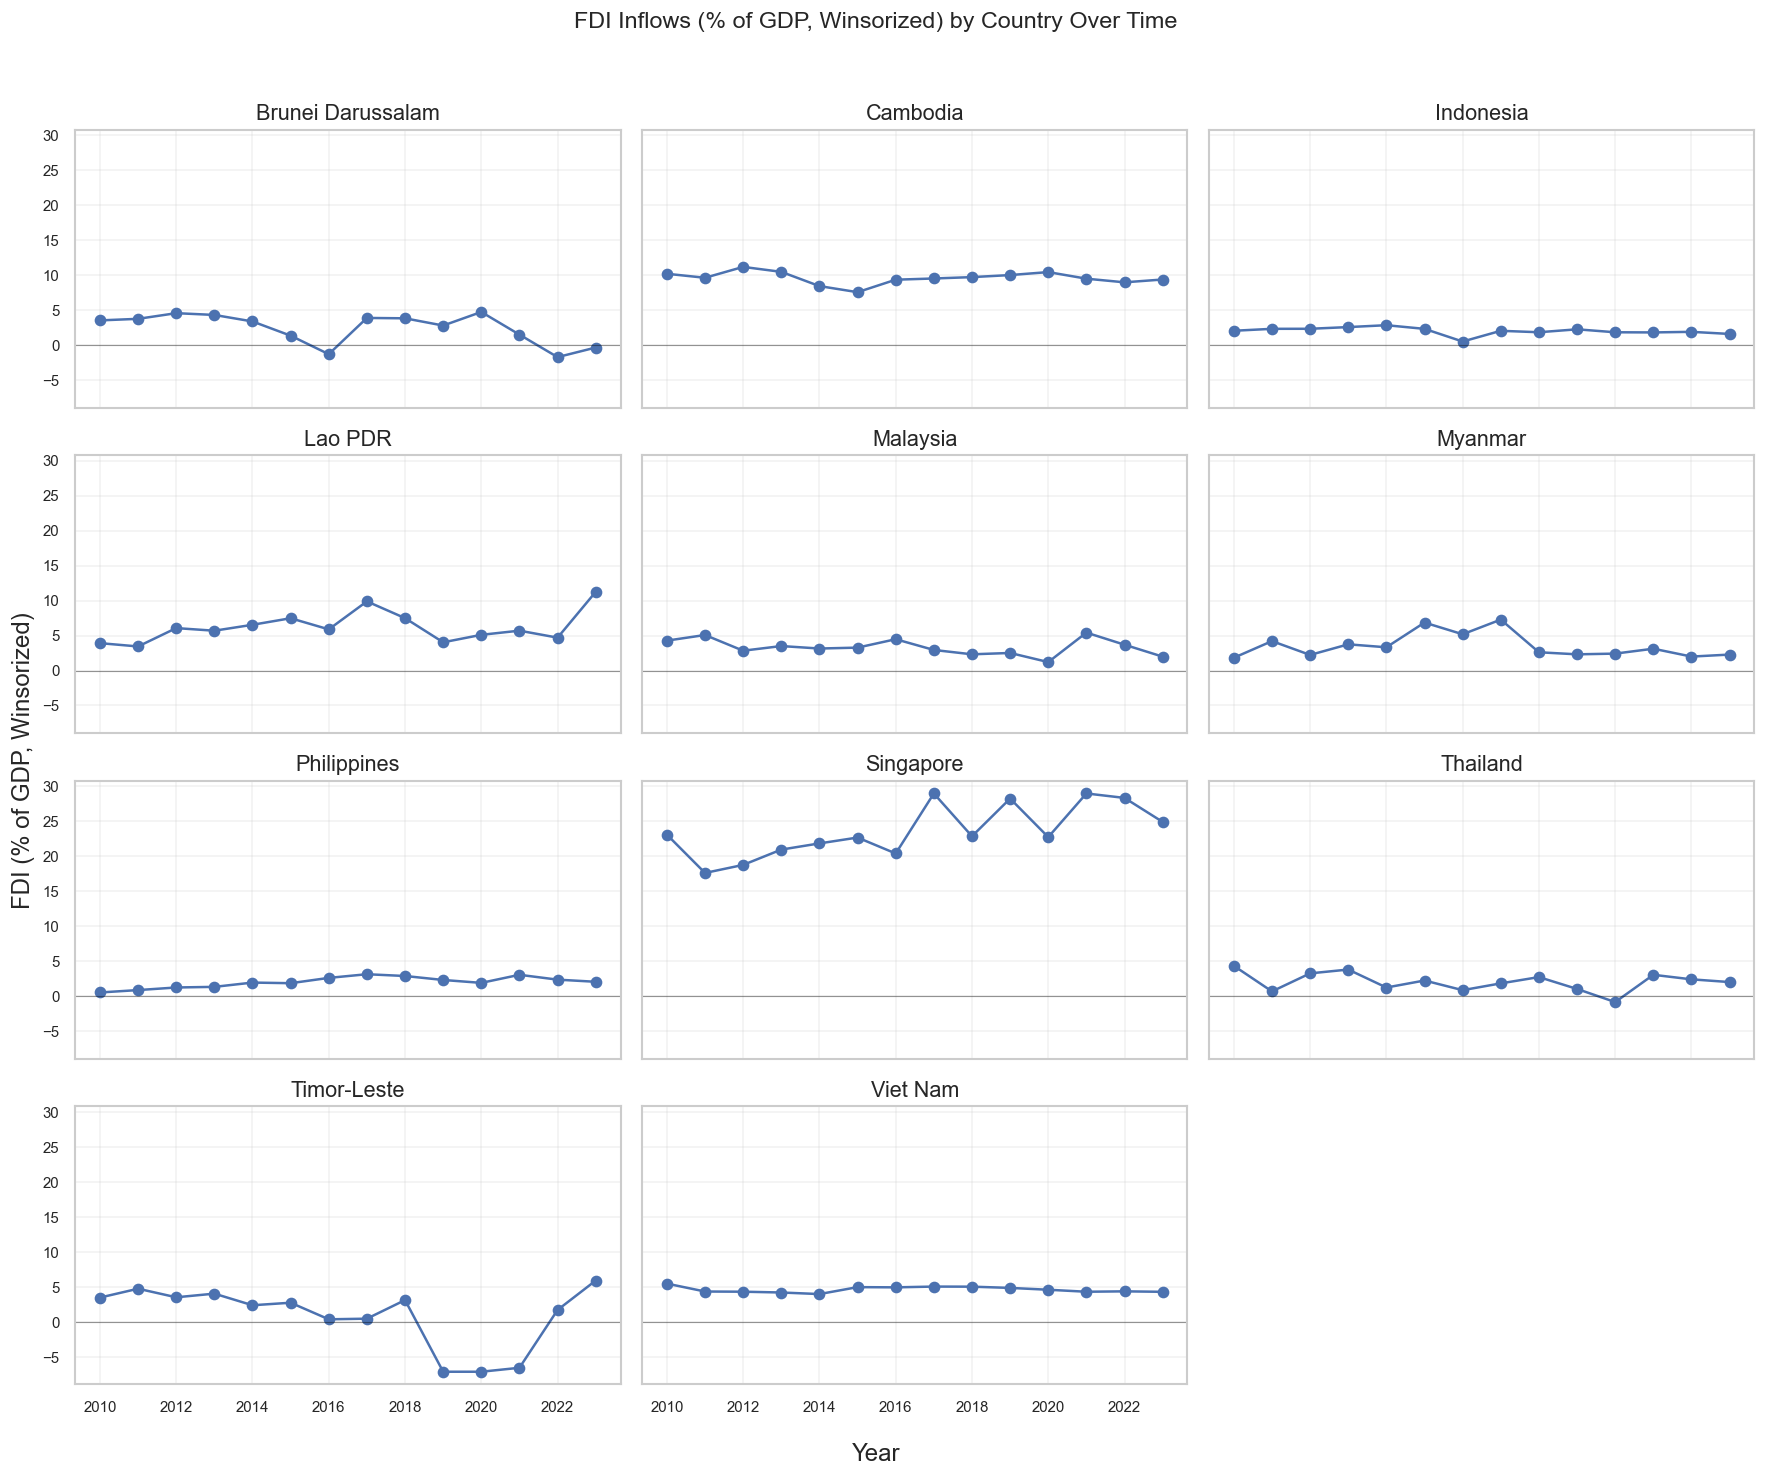

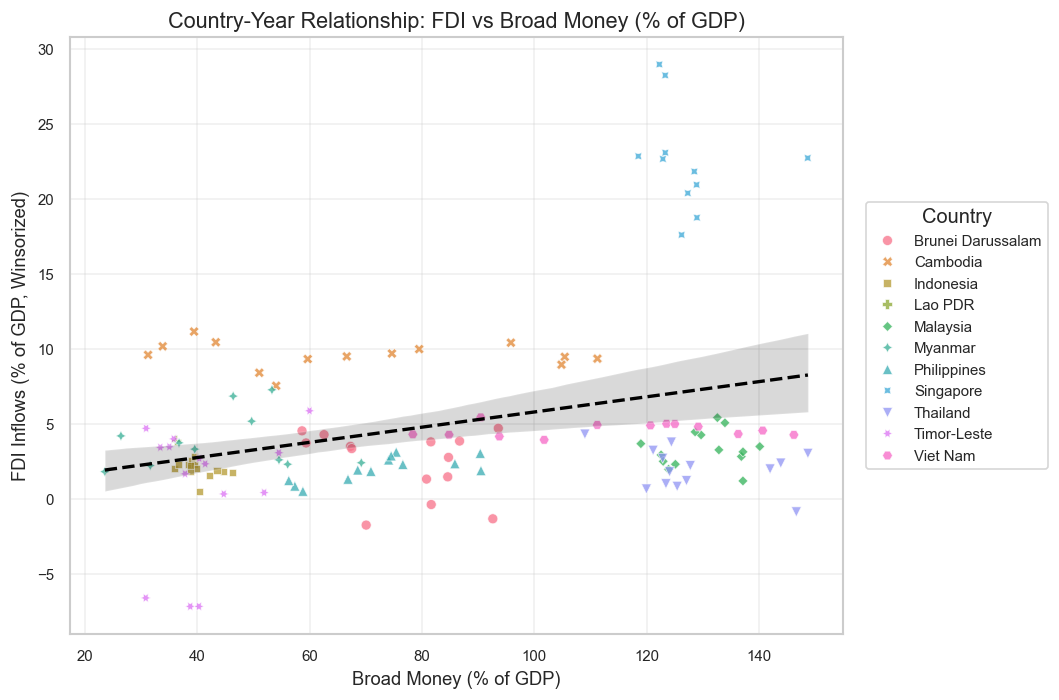

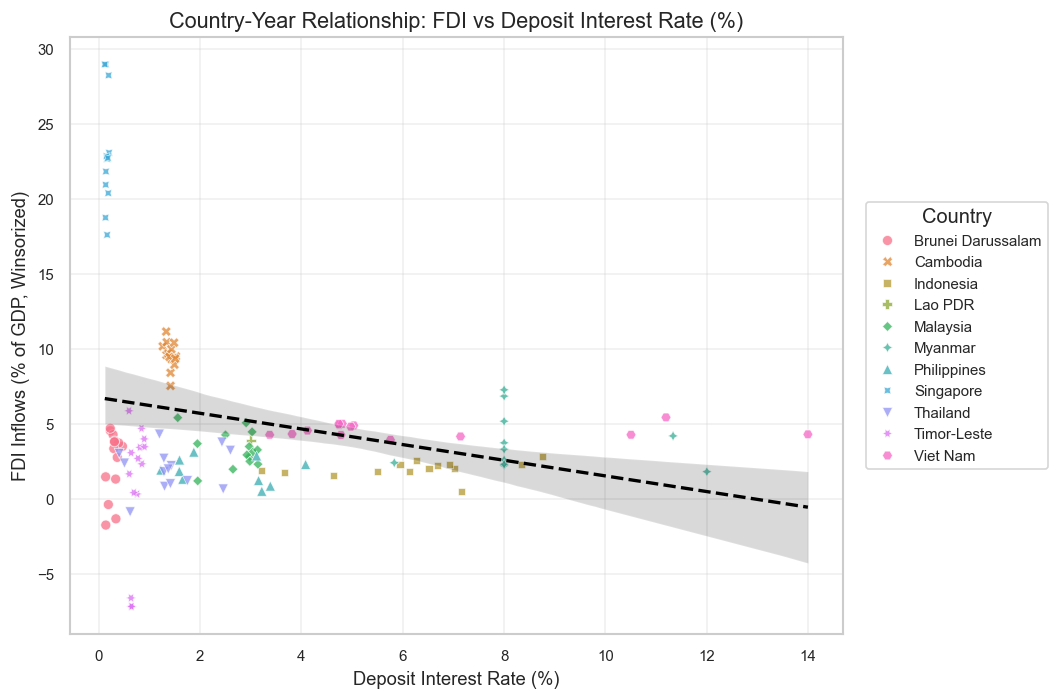

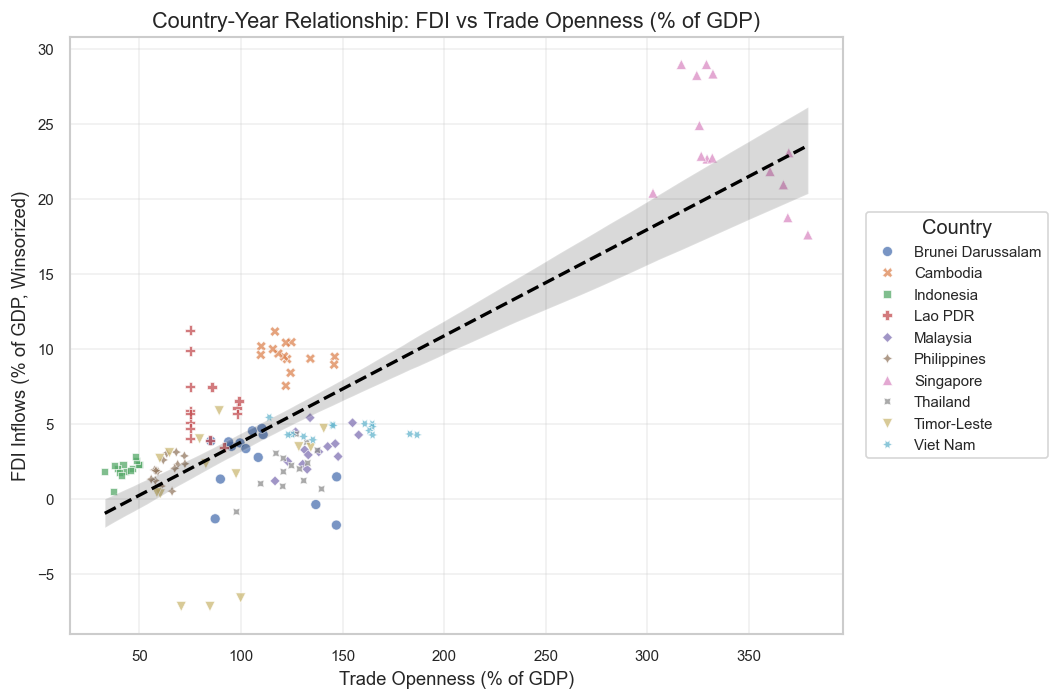

In [11]:

# -----------------------------
# Year-country visualizations
# -----------------------------
def year_country_heatmap(df, var, label, filename, center=None):
    panel = df.pivot_table(index='country', columns='year', values=var, aggfunc='mean')
    panel = panel.dropna(how='all')
    if panel.empty:
        return

    fig, ax = plt.subplots(figsize=(12, max(6, 0.35 * len(panel))))
    sns.heatmap(panel, cmap='viridis', linewidths=0.2, linecolor='white', center=center, ax=ax)
    ax.set_title(f'Country-Year Heatmap: {label}')
    ax.set_xlabel('Year')
    ax.set_ylabel('Country')
    plt.tight_layout()
    save_figure(fig, filename, FIGURES_DIR)
    plt.show()

heatmap_specs = [
    ('fdi_pct_gdp_winsorized', 'FDI Inflows (% of GDP, Winsorized)', 'heatmap_country_year_fdi.png', None),
    ('broad_money_pct_gdp', 'Broad Money (% of GDP)', 'heatmap_country_year_broad_money.png', None),
    ('deposit_interest_rate_pct', 'Deposit Interest Rate (%)', 'heatmap_country_year_deposit_interest.png', None),
    ('xr_dep_pct_winsorized', 'Exchange Rate Depreciation (%, Winsorized)', 'heatmap_country_year_xr_dep.png', 0)
]
for var, label, filename, center in heatmap_specs:
    if var in df.columns:
        year_country_heatmap(df, var, label, filename, center=center)

# Panel missingness heatmap for the dependent variable and core regressors
panel_key_vars = [
    'fdi_pct_gdp_winsorized',
    'broad_money_pct_gdp',
    'deposit_interest_rate_pct',
    'real_interest_rate_pct',
    'inflation_gdp_deflator_pct',
    'trade_pct_gdp',
    'ln_gdppc',
    'xr_dep_pct_winsorized'
]
panel_key_vars = [v for v in panel_key_vars if v in df.columns]
if panel_key_vars:
    df_panel = df.copy()
    df_panel['complete_selected_vars'] = df_panel[panel_key_vars].notna().all(axis=1).astype(int)
    completeness_panel = df_panel.pivot_table(index='country', columns='year', values='complete_selected_vars', aggfunc='mean')

    fig, ax = plt.subplots(figsize=(12, max(6, 0.35 * len(completeness_panel))))
    sns.heatmap(completeness_panel, cmap='Blues', linewidths=0.2, linecolor='white', cbar_kws={'label': 'Complete row indicator'}, ax=ax)
    ax.set_title('Country-Year Completeness for Selected Variables')
    ax.set_xlabel('Year')
    ax.set_ylabel('Country')
    plt.tight_layout()
    save_figure(fig, 'heatmap_country_year_completeness_selected_vars.png', FIGURES_DIR)
    plt.show()

# Small multiples: FDI trends by country
if 'fdi_pct_gdp_winsorized' in df.columns:
    countries = sorted(df['country'].dropna().unique())
    n_countries = len(countries)
    n_cols = 3
    n_rows = int(np.ceil(n_countries / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, max(4, 3 * n_rows)), sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)

    for ax, country in zip(axes, countries):
        country_df = df[df['country'] == country].sort_values('year')
        ax.plot(country_df['year'], country_df['fdi_pct_gdp_winsorized'], marker='o', linewidth=1.5)
        ax.axhline(0, color='black', linewidth=0.7, alpha=0.4)
        ax.set_title(country)
        ax.grid(True, alpha=0.25)

    for ax in axes[n_countries:]:
        ax.set_visible(False)

    fig.suptitle('FDI Inflows (% of GDP, Winsorized) by Country Over Time', y=1.02, fontsize=14)
    fig.supxlabel('Year')
    fig.supylabel('FDI (% of GDP, Winsorized)')
    plt.tight_layout()
    save_figure(fig, 'small_multiples_country_fdi_trends.png', FIGURES_DIR)
    plt.show()

# Year-country scatter with pooled trend and country coloring
scatter_specs = [
    ('broad_money_pct_gdp', 'Broad Money (% of GDP)', 'scatter_country_year_broad_money_fdi.png'),
    ('deposit_interest_rate_pct', 'Deposit Interest Rate (%)', 'scatter_country_year_deposit_interest_fdi.png'),
    ('trade_pct_gdp', 'Trade Openness (% of GDP)', 'scatter_country_year_trade_fdi.png')
]
for x_var, x_label, filename in scatter_specs:
    if x_var in df.columns and 'fdi_pct_gdp_winsorized' in df.columns:
        plot_df = df[[x_var, 'fdi_pct_gdp_winsorized', 'country', 'year']].dropna()
        if not plot_df.empty:
            fig, ax = plt.subplots(figsize=(9, 6))
            sns.scatterplot(data=plot_df, x=x_var, y='fdi_pct_gdp_winsorized', hue='country', style='country', alpha=0.75, ax=ax)
            sns.regplot(data=plot_df, x=x_var, y='fdi_pct_gdp_winsorized', scatter=False, color='black', line_kws={'lw': 2, 'linestyle': '--'}, ax=ax)
            ax.set_title(f'Country-Year Relationship: FDI vs {x_label}')
            ax.set_xlabel(x_label)
            ax.set_ylabel('FDI Inflows (% of GDP, Winsorized)')
            ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), title='Country')
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            save_figure(fig, filename, FIGURES_DIR)
            plt.show()
